# 02 Parking Sensor Cleaning and EDA with DuckDB

## Purpose
This notebook uses DuckDB to clean, validate, and explore the City of Melbourne parking sensor data (2011–2020) for the project streets. The notebook reads the processed dataset (`parking_sensor_project_streets.csv`) created by `01_sensor_data_preparation.ipynb` without loading the complete dataset into Python memory.

This notebook focuses on:
- Loading the processed dataset into DuckDB
- Performing additional validation where required
- Cleaning the dataset where required
- Performing exploratory data analysis (EDA)
- Preparing the dataset for parking utilisation analysis

#### Improt Libraries

In [135]:
# Import libraries
from pathlib import Path
import duckdb
import pandas as pd

#### Set File Paths

In [136]:
# Project folder
project_folder = Path("../../../")

# Processed data folder
processed_folder = project_folder / "data" / "processed"

# DuckDB database folder
database_folder = project_folder / "data" / "database"
database_folder.mkdir(exist_ok=True)

# Database file
database_file = database_folder / "parking_sensor.duckdb"

#### Connect to DuckDB

In [137]:
# Connect to DuckDB
con = duckdb.connect(database_file)
print("Connected successfully.")

Connected successfully.


#### Load the Project Dataset

In [138]:
# Path to the project street dataset
sensor_file = processed_folder / "parking_sensor_project_streets.csv"
print(sensor_file)

../../../data/processed/parking_sensor_project_streets.csv


#### Load CSV into DuckDB

In [139]:
# Create DuckDB table
con.execute(f"""
CREATE OR REPLACE TABLE parking_sensor AS
SELECT *
FROM read_csv_auto('{sensor_file}');
""")

#### Validate Imported Data

In [140]:
# Validate Imported Data
validation = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT street_name) AS unique_streets,
        MIN(source_year) AS earliest_year,
        MAX(source_year) AS latest_year
    FROM parking_sensor
""").df()

validation

,total_rows,unique_streets,earliest_year,latest_year
0,180825983,22,2011,2020


### 1. Data Quality Check (Before cleaning)
Perform basic data quality checks to verify the merged dataset before data cleaning and exploratory data analysis.

#### Dataset Size

Check the total number of rows and columns in the parking sensor dataset.

In [ ]:
# Count the number of rows
import pandas as pd

# Number of rows
total_rows = con.sql("""
SELECT COUNT(*) AS total_rows
FROM parking_sensor;
""").fetchone()[0]

# Number of columns
total_columns = len(
    con.sql("""
    DESCRIBE parking_sensor;
    """).df()
)

dataset_size = pd.DataFrame({
    "Measurement": [
        "Number of rows",
        "Number of columns"
    ],
    "Value": [
        total_rows,
        total_columns
    ]
})

dataset_size

,Measurement,Value
0,Number of rows,180825983
1,Number of columns,21


#### Data Types
Check the data type of each column.

In [ ]:
# Check the data types of all columns
data_types = con.execute("""
    DESCRIBE parking_sensor
""").fetchdf()

data_types

,column_name,column_type,null,key,default,extra
0,device_id,VARCHAR,YES,None,None,None
1,arrival_time,TIMESTAMP,YES,None,None,None
2,departure_time,TIMESTAMP,YES,None,None,None
3,duration_seconds,VARCHAR,YES,None,None,None
4,street_marker,VARCHAR,YES,None,None,None
5,sign,VARCHAR,YES,None,None,None
6,area,VARCHAR,YES,None,None,None
7,street_id,VARCHAR,YES,None,None,None
8,street_name,VARCHAR,YES,None,None,None
9,between_street_1,VARCHAR,YES,None,None,None


#### Missing Values
Check the number of missing values for every column.

In [143]:
# Display only columns containing missing values
missing_queries = []

for column in column_names:
    missing_queries.append(f"""
        SELECT
            '{column}' AS column_name,
            COUNT(*) FILTER (
                WHERE "{column}" IS NULL
            ) AS missing_values
        FROM parking_sensor
        HAVING COUNT(*) FILTER (
            WHERE "{column}" IS NULL
        ) > 0
    """)

missing_sql = "\nUNION ALL\n".join(missing_queries)

con.execute(missing_sql).fetchdf().sort_values(
    by="missing_values",
    ascending=False
).reset_index(drop=True)

,column_name,missing_values
0,side_of_street_code,161265923
1,sign_plate_id,154864917
2,between_street_1_id,141268627
3,between_street_2_id,141268627
4,side_name,141268627
5,bay_id,141268627
6,sign,29513777
7,duration_seconds,5897
8,area,383


#### Duplicate Records
Check compares the total number of rows with the number of completely unique rows. This check displays sample duplicate records to verify whether they are exact duplicates before deciding whether they should be removed from the dataset.

In [144]:
# Count complete duplicate records
duplicate_df = con.execute("""
    SELECT
        total_rows,
        unique_rows,
        total_rows - unique_rows AS duplicate_rows
    FROM (
        SELECT
            (SELECT COUNT(*) FROM parking_sensor) AS total_rows,
            (
                SELECT COUNT(*)
                FROM (
                    SELECT DISTINCT *
                    FROM parking_sensor
                )
            ) AS unique_rows
    )
""").fetchdf()

duplicate_df

,total_rows,unique_rows,duplicate_rows
0,180825983,180686173,139810


In [145]:
# Display sample duplicate rows
con.execute("""
    SELECT
        *,
        COUNT(*) AS duplicate_count
    FROM parking_sensor
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY duplicate_count DESC
    LIMIT 20
""").fetchdf()

,device_id,arrival_time,departure_time,duration_seconds,street_marker,sign,area,street_id,street_name,between_street_1,...,in_violation,vehicle_present,source_year,sign_plate_id,between_street_1_id,between_street_2_id,side_name,bay_id,side_of_street_code,duplicate_count
0,"9,693",2014-10-07 07:30:00,2014-10-07 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
1,"9,693",2014-10-22 07:30:00,2014-10-22 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
2,"9,693",2014-10-27 07:30:00,2014-10-27 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
3,"9,693",2014-11-07 07:30:00,2014-11-07 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
4,"9,693",2014-10-20 07:30:00,2014-10-20 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
5,"9,693",2014-11-10 07:30:00,2014-11-10 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
6,"9,693",2014-10-31 07:30:00,2014-10-31 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
7,"9,693",2014-10-24 07:30:00,2014-10-24 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
8,"9,693",2014-10-03 07:30:00,2014-10-03 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164
9,"9,693",2014-09-24 07:30:00,2014-09-24 19:30:00,"43,200",C2922,1P MTR M-SAT 7:30-19:30,Hardware,894,LONSDALE STREET,QUEEN STREET,...,False,False,2014,None,None,None,None,None,None,164


#### Invalid Parking Duration
Parking duration should not be negative. This check counts negative, zero, and missing duration values. This check displays invalid parking duration before deciding whether they should be removed from the dataset.

In [146]:
# Check invalid parking duration values
duration_quality_df = con.execute("""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (
        WHERE TRY_CAST(
            REPLACE(duration_seconds, ',', '')
            AS DOUBLE
        ) < 0
    ) AS negative_duration,

    COUNT(*) FILTER (
        WHERE TRY_CAST(
            REPLACE(duration_seconds, ',', '')
            AS DOUBLE
        ) = 0
    ) AS zero_duration,

    COUNT(*) FILTER (
        WHERE duration_seconds IS NULL
           OR TRIM(duration_seconds) = ''
    ) AS missing_duration,

    COUNT(*) FILTER (
        WHERE TRY_CAST(
            REPLACE(duration_seconds, ',', '')
            AS DOUBLE
        ) > 0
    ) AS positive_duration

FROM parking_sensor
""").fetchdf()

duration_quality_df

,total_rows,negative_duration,zero_duration,missing_duration,positive_duration
0,180825983,1358,4623189,5897,176195539


In [147]:
# Negative duration
con.execute("""
SELECT *
FROM parking_sensor
WHERE TRY_CAST(duration_seconds AS DOUBLE) < 0
LIMIT 20
""").fetchdf()

,device_id,arrival_time,departure_time,duration_seconds,street_marker,sign,area,street_id,street_name,between_street_1,...,side_of_street,in_violation,vehicle_present,source_year,sign_plate_id,between_street_1_id,between_street_2_id,side_name,bay_id,side_of_street_code
0,"12,218",2014-10-04 23:59:11,2014-10-04 23:59:00,-11,3607S,P10 M-SUN 0:00-23:59,Regency,856,LA TROBE STREET,EXHIBITION STREET,...,4.0,False,False,2014,None,None,None,None,None,None
1,"11,974",2014-10-04 23:59:16,2014-10-04 23:59:00,-16,1286E,2P DIS M-SUN 0:00-23:59 OLD,Titles,"1,171",QUEEN STREET,LA TROBE STREET,...,2.0,False,False,2014,None,None,None,None,None,None
2,"12,283",2014-10-02 23:59:18,2014-10-02 23:59:00,-18,3760N,P/10 M-SUN 0:00-23:59 - No Park,The Mac,856,LA TROBE STREET,ELIZABETH STREET,...,3.0,False,False,2014,None,None,None,None,None,None
3,"14,536",2014-09-30 23:59:17,2014-09-30 23:59:00,-17,3766N,1/4P M-SUN 0:00-23:59,The Mac,856,LA TROBE STREET,ELIZABETH STREET,...,3.0,False,False,2014,None,None,None,None,None,None
4,"11,800",2014-11-04 23:59:07,2014-11-04 23:59:00,-7,10033S,4P DIS ONLY M-SUN,Southbank,"1,278",SOUTHBANK BOULEVARD,STURT STREET,...,4.0,False,False,2014,None,None,None,None,None,None
5,"11,799",2014-10-09 23:59:04,2014-10-09 23:59:00,-4,10031S,4P DIS ONLY M-SUN,Southbank,"1,278",SOUTHBANK BOULEVARD,STURT STREET,...,4.0,False,False,2014,None,None,None,None,None,None
6,"15,338",2014-11-05 23:59:13,2014-11-05 23:59:00,-13,8651W,1/4P M-SUN 0:00-23:59,Southbank,828,KAVANAGH STREET,BALSTON STREET,...,5.0,False,False,2014,None,None,None,None,None,None
7,"11,799",2014-11-05 23:59:13,2014-11-05 23:59:00,-13,10031S,4P DIS ONLY M-SUN,Southbank,"1,278",SOUTHBANK BOULEVARD,STURT STREET,...,4.0,False,False,2014,None,None,None,None,None,None
8,"11,799",2014-10-03 23:59:02,2014-10-03 23:59:00,-2,10031S,4P DIS ONLY M-SUN,Southbank,"1,278",SOUTHBANK BOULEVARD,STURT STREET,...,4.0,False,False,2014,None,None,None,None,None,None
9,"13,885",2014-11-02 23:59:09,2014-11-02 23:59:00,-9,13278N,LZ 15M M-SUN 0:00-23:59,Docklands,856,LA TROBE STREET,HARBOUR ESPLANADE,...,3.0,False,False,2014,None,None,None,None,None,None


In [148]:
# Zero duration
con.execute("""
SELECT *
FROM parking_sensor
WHERE TRY_CAST(duration_seconds AS DOUBLE) = 0
LIMIT 20
""").fetchdf()

,device_id,arrival_time,departure_time,duration_seconds,street_marker,sign,area,street_id,street_name,between_street_1,...,side_of_street,in_violation,vehicle_present,source_year,sign_plate_id,between_street_1_id,between_street_2_id,side_name,bay_id,side_of_street_code
0,"3,524",2011-11-09 09:30:00,2011-11-09 09:30:00,0,4613W,1P MTR M-F 9:30-16:00,The Mac,"1,329",SWANSTON STREET,FRANKLIN STREET,...,5.0,False,False,2011,None,None,None,None,None,None
1,"1,177",2011-12-01 18:00:00,2011-12-01 18:00:00,0,1571W,2P MTR M-F 18:00-2030,Magistrates,"1,285",SPENCER STREET,Lt LONSDALE STREET,...,5.0,False,False,2011,None,None,None,None,None,None
2,149,2011-10-27 09:30:00,2011-10-27 09:30:00,0,622E,2P MTR M-F 9:30-20:30,Regency,647,EXHIBITION STREET,LA TROBE STREET,...,2.0,False,False,2011,None,None,None,None,None,None
3,368,2011-08-16 07:30:00,2011-08-16 07:30:00,0,C638,2P MTR M-SAT 7:30-20:30,Regency,647,EXHIBITION STREET,LA TROBE STREET,...,1.0,False,False,2011,None,None,None,None,None,None
4,"17,209",2011-01-02 20:05:45,2011-01-02 20:05:45,0,13045S,NaN,Docklands,528,COLLINS STREET,HARBOUR ESPLANADE,...,4.0,False,False,2011,None,None,None,None,None,None
5,"17,183",2011-01-03 00:00:00,2011-01-03 00:00:00,0,13015S,NaN,Docklands,528,COLLINS STREET,SPENCER STREET,...,4.0,False,False,2011,None,None,None,None,None,None
6,866,2011-09-12 18:00:00,2011-09-12 18:00:00,0,1544E,1/2P MTR M-F 18:00-19:30,Spencer,"1,285",SPENCER STREET,Lt BOURKE STREET,...,2.0,False,False,2011,None,None,None,None,None,None
7,"1,859",2011-11-16 09:30:00,2011-11-16 09:30:00,0,3281S,2P DIS AOT 9:30-23:59,County,894,LONSDALE STREET,KING STREET,...,4.0,False,False,2011,None,None,None,None,None,None
8,"17,209",2011-01-02 12:23:56,2011-01-02 12:23:56,0,13045S,NaN,Docklands,528,COLLINS STREET,HARBOUR ESPLANADE,...,4.0,False,False,2011,None,None,None,None,None,None
9,"17,217",2011-01-01 11:27:21,2011-01-01 11:27:21,0,13061S,P5 M-SUN 0:00-23:59,Docklands,528,COLLINS STREET,NAVIGATION DRIVE,...,4.0,False,False,2011,None,None,None,None,None,None


In [149]:
# Missing Duration (Null)
con.execute("""
SELECT *
FROM parking_sensor
WHERE duration_seconds IS NULL
LIMIT 20
""").fetchdf()


,device_id,arrival_time,departure_time,duration_seconds,street_marker,sign,area,street_id,street_name,between_street_1,...,side_of_street,in_violation,vehicle_present,source_year,sign_plate_id,between_street_1_id,between_street_2_id,side_name,bay_id,side_of_street_code
0,17175,2018-09-29 01:20:22,2018-09-29 23:49:30,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
1,17175,2018-05-06 00:00:00,2018-05-06 18:45:07,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
2,17175,2018-04-07 00:00:00,2018-04-07 17:34:59,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
3,17175,2018-10-07 03:00:04,2018-10-08 00:00:00,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
4,17175,2018-12-30 00:10:36,2018-12-30 23:11:22,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
5,17173,2018-07-01 00:00:00,2018-07-01 17:05:09,None,13006N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6655.0,None
6,17173,2018-10-14 00:00:00,2018-10-14 22:27:53,None,13006N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6655.0,None
7,17175,2018-01-20 00:00:00,2018-01-21 00:00:00,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
8,17175,2018-01-21 00:00:00,2018-01-21 22:34:15,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None
9,17175,2018-06-30 02:25:46,2018-07-01 00:00:00,None,13008N,P/10 MINS NO PARKING M-SUN 0:00 TO 23:59,Docklands,528,COLLINS STREET,SPENCER STREET,...,3.0,False,False,2018,532.0,1285.0,79,North,6044.0,None


#### Date range
This check verifies the date range of the dataset to ensure that it covers the expected time period and contains no unexpected dates.

In [150]:
# Check the date range for each source year
con.execute("""
SELECT
    source_year,
    MIN(arrival_time) AS earliest_arrival,
    MAX(arrival_time) AS latest_arrival,
    COUNT(*) AS total_records
FROM parking_sensor
GROUP BY source_year
ORDER BY source_year
""").fetchdf()

,source_year,earliest_arrival,latest_arrival,total_records
0,2011,2011-01-01 01:21:09,2011-12-31 23:58:43,11533807
1,2012,2012-01-01 00:00:00,2012-12-31 23:57:48,29292889
2,2013,2013-01-01 00:00:00,2013-12-31 23:56:15,24705963
3,2014,2014-01-01 00:00:00,2014-12-31 23:59:00,27068866
4,2015,2015-01-01 00:00:00,2015-12-31 23:56:01,17313692
5,2016,2016-01-01 00:00:00,2016-12-31 23:57:03,15368217
6,2017,2017-01-01 00:00:00,2017-12-31 23:57:53,15985193
7,2018,2018-01-01 00:00:00,2018-12-31 23:55:54,13952708
8,2019,2019-01-01 00:00:00,2019-12-31 23:59:22,19560060
9,2020,2020-01-01 00:00:00,2020-05-26 11:20:21,6044588


In [151]:
# Check the number of available months for each year
available_months_df = con.execute("""
SELECT
    source_year,
    COUNT(DISTINCT MONTH(arrival_time)) AS available_months
FROM parking_sensor
GROUP BY source_year
ORDER BY source_year
""").fetchdf()

available_months_df

,source_year,available_months
0,2011,7
1,2012,12
2,2013,12
3,2014,12
4,2015,12
5,2016,12
6,2017,12
7,2018,12
8,2019,12
9,2020,5


In [152]:
# Identify missing months for each year
missing_months_df = con.execute("""
WITH expected_months AS (
    SELECT
        year_value AS source_year,
        month_value AS month_number
    FROM RANGE(2011, 2021) AS years(year_value)
    CROSS JOIN RANGE(1, 13) AS months(month_value)
),

available_months AS (
    SELECT DISTINCT
        source_year,
        MONTH(arrival_time) AS month_number
    FROM parking_sensor
    WHERE arrival_time IS NOT NULL
)

SELECT
    e.source_year,
    e.month_number,
    STRFTIME(
        MAKE_DATE(e.source_year, e.month_number, 1),
        '%B'
    ) AS missing_month
FROM expected_months e
LEFT JOIN available_months a
    ON e.source_year = a.source_year
   AND e.month_number = a.month_number
WHERE a.month_number IS NULL
ORDER BY
    e.source_year,
    e.month_number
""").fetchdf()

missing_months_df

,source_year,month_number,missing_month
0,2011,2,February
1,2011,3,March
2,2011,4,April
3,2011,5,May
4,2011,6,June
5,2020,6,June
6,2020,7,July
7,2020,8,August
8,2020,9,September
9,2020,10,October


The monthly coverage check shows that the filtered data for the selected project streets is incomplete for 2011 and 2020. The 2011 data contains seven months of records, while the 2020 data contains five months. This may be caused by limited sensor coverage on the selected streets, rather than missing data in the original datasets.

### 2. Data Cleaning
This section removes invalid records, handles missing values, and prepares the dataset for further analysis.

#### Remove exact duplicate records
The data quality assessment identified 139,810 exact duplicate records. These records contain identical values across all columns and provide no additional information. Therefore, duplicate records are removed before further analysis.

#### Remove records with negative duration 
Records with negative parking durations were removed because a departure time cannot occur before an arrival time.

#### Remove records with missing duration
Records with missing parking duration values were removed because duration is required for the parking utilisation analysis.

#### Remove records with zero
Records with zero parking duration were removed because they do not represent valid parking durations for parking utilisation analysis.


In [153]:
# Create one cleaned view
con.execute("""
CREATE OR REPLACE VIEW parking_sensor_clean AS

SELECT DISTINCT
    * EXCLUDE (duration_seconds),

    TRY_CAST(
        REPLACE(duration_seconds, ',', '')
        AS DOUBLE
    ) AS duration_seconds

FROM parking_sensor

WHERE duration_seconds IS NOT NULL
  AND TRIM(duration_seconds) <> ''
  AND TRY_CAST(
        REPLACE(duration_seconds, ',', '')
        AS DOUBLE
      ) > 0
""")

In [154]:
# Verify the cleaned dataset
con.execute("""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) - (
        SELECT COUNT(*)
        FROM (
            SELECT DISTINCT *
            FROM parking_sensor_clean
        )
    ) AS duplicate_rows,

    COUNT(*) FILTER (
        WHERE duration_seconds IS NULL
    ) AS missing_duration,

    COUNT(*) FILTER (
        WHERE duration_seconds < 0
    ) AS negative_duration,

    COUNT(*) FILTER (
        WHERE duration_seconds = 0
    ) AS zero_duration

FROM parking_sensor_clean
""").fetchdf()

,total_rows,duplicate_rows,missing_duration,negative_duration,zero_duration
0,176055769,0,0,0,0


### 3. Join Parking Sensor Data with Project Streets
The parking sensor dataset contains records from the City of Melbourne. However, the project street dataset contains streets from different LGAs, including metropolitan and regional areas.

Some streets may have the same name but be located in different cities. Therefore, the project street dataset is filtered to the City of Melbourne before joining. This helps prevent incorrect matches between streets with the same name in different locations.

In [155]:
project_root = Path.cwd().parents[2]
street_file = project_root / "data" / "raw" / "street_spatial.csv"

# Load street_spatial.csv into DuckDB
con.execute(f"""
CREATE OR REPLACE TABLE street_spatial AS
SELECT *
FROM read_csv_auto('{street_file.as_posix()}')
""")

#### Check the Available LGAs
The project street dataset contains streets from several local government areas. This check identifies the available LGA values before selecting streets located within the City of Melbourne.

In [156]:
# Display the available LGA values
con.execute("""
SELECT
    lga,
    COUNT(*) AS segment_count
FROM street_spatial
GROUP BY lga
ORDER BY segment_count DESC
""").fetchdf()

,lga,segment_count
0,Melbourne (C),83
1,Stonnington (C),25
2,Port Phillip (C),21
3,Boroondara (C),20
4,Glen Eira (C),19
5,Yarra (C),16
6,Kingston (C) (Vic.),13
7,Moonee Valley (C),13
8,Banyule (C),13
9,Darebin (C),12


#### Filter City of Melbourne Streets
The parking sensor dataset is provided by the City of Melbourne. Therefore, only project streets located within the City of Melbourne are retained for the join.

This also prevents streets with the same name in other cities or LGAs from being incorrectly matched with the parking sensor records.

In [157]:
# Keep only project streets located in the City of Melbourne
con.execute("""
CREATE OR REPLACE VIEW street_spatial_melbourne AS

SELECT *
FROM street_spatial
WHERE lga = 'Melbourne (C)'
""")

#### Check the Filtered Street Data
This check confirms the number of street segments and unique street names remaining after filtering to the City of Melbourne.

In [158]:
# Check the size of the filtered street dataset
con.execute("""
SELECT
    COUNT(*) AS total_segments,
    COUNT(DISTINCT street_name) AS unique_streets
FROM street_spatial_melbourne
""").fetchdf()

,total_segments,unique_streets
0,83,29


#### Check Duplicate Street Names
A street name may appear more than once because one street can contain multiple street segments. This check identifies street names that appear in more than one segment.

In [159]:
# Check for duplicate street names in the City of Melbourne
con.execute("""
SELECT
    street_name,
    COUNT(*) AS street_count
FROM street_spatial_melbourne
GROUP BY street_name
HAVING COUNT(*) > 1
ORDER BY street_count DESC
""").fetchdf()

,street_name,street_count
0,LA TROBE STREET,8
1,SOUTHBANK BOULEVARD,7
2,COLLINS STREET,6
3,LONSDALE STREET,6
4,ABBOTSFORD STREET,5
5,ALBERT STREET,5
6,WILLIAM STREET,4
7,BOURKE ST,3
8,SWANSTON STREET,3
9,WELLINGTON PARADE,3


#### Check Treatment and Control Consistency
Before joining by street name, this check confirms that each street name belongs to only one treatment or control category.

If the same street name contains both treatment and control segments, joining by street name would not be reliable.

In [160]:
# Check whether each street belongs to only one treatment or control category
con.execute("""
SELECT
    street_name,
    COUNT(DISTINCT treatment_or_control) AS category_count,
    STRING_AGG(
        DISTINCT treatment_or_control,
        ', '
    ) AS categories
FROM street_spatial_melbourne
GROUP BY street_name
HAVING COUNT(DISTINCT treatment_or_control) > 1
ORDER BY street_name
""").fetchdf()

,street_name,category_count,categories


An empty DataFrame means that no street name belongs to both treatment and control categories. Each street name has only one category.

#### Create a Street-Level Mapping
The project street dataset contains multiple segments for some street names. To prevent the parking sensor records from being duplicated during the join, one record is created for each street name.

The mapping stores the treatment/control category and intervention type for each City of Melbourne street.

In [161]:
# Create one treatment/control record for each City of Melbourne street
con.execute("""
CREATE OR REPLACE VIEW street_mapping_melbourne AS

SELECT
    UPPER(TRIM(street_name)) AS street_name,
    MIN(treatment_or_control) AS treatment_or_control,
    MIN(intervention_type) AS intervention_type

FROM street_spatial_melbourne

GROUP BY
    UPPER(TRIM(street_name))
""")

In [162]:
# Display the street-level mapping
con.execute("""
SELECT *
FROM street_mapping_melbourne
ORDER BY street_name
""").fetchdf()

,street_name,treatment_or_control,intervention_type
0,ABBOTSFORD STREET,treatment,protected bike lane
1,ALBERT STREET,treatment,protected bike lane
2,ANZAC AVENUE,treatment,protected bike lane
3,BOURKE ST,control,control
4,CITY ROAD,treatment,protected bike lane
5,COLLINS STREET,control,control
6,ERROL ST,control,control
7,EXHIBITION STREET,treatment,protected bike lane
8,GOVERNMENT HOUSE DRIVE,treatment,protected bike lane
9,KAVANAGH STREET,treatment,protected bike lane


In [163]:
# Confirm that each street appears only once in the mapping
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT street_name) AS unique_streets
FROM street_mapping_melbourne
""").fetchdf()

,total_rows,unique_streets
0,29,29


#### Join the Datasets 
The cleaned parking sensor data is joined with the City of Melbourne street mapping using the standardised street name.

A left join is used to keep all parking sensor records. Records that do not match the project street mapping can then be identified and investigated.

In [164]:
# Join cleaned parking sensor records with the City of Melbourne street mapping
con.execute("""
CREATE OR REPLACE VIEW parking_sensor_analysis AS

SELECT
    p.*,
    s.treatment_or_control,
    s.intervention_type

FROM parking_sensor_clean AS p

LEFT JOIN street_mapping_melbourne AS s
    ON UPPER(TRIM(p.street_name)) = s.street_name
""")

#### Check Matched and Unmatched Records
This check measures how many parking sensor records successfully received treatment/control information from the project street mapping.

In [165]:
# Check the number of matched and unmatched records
con.execute("""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (
        WHERE treatment_or_control IS NOT NULL
    ) AS matched_rows,

    COUNT(*) FILTER (
        WHERE treatment_or_control IS NULL
    ) AS unmatched_rows

FROM parking_sensor_analysis
""").fetchdf()

,total_rows,matched_rows,unmatched_rows
0,176055769,161842106,14213663


In [166]:
# Display unmatched street names and their record counts
con.execute("""
SELECT
    street_name,
    COUNT(*) AS record_count
FROM parking_sensor_analysis
WHERE treatment_or_control IS NULL
GROUP BY street_name
ORDER BY record_count DESC
""").fetchdf()

,street_name,record_count
0,ELIZABETH STREET,10486438
1,CLARENDON STREET,3675191
2,ACLAND STREET,52034


In [170]:
# Check the location information for the unmatched streets
con.execute("""
SELECT
    street_name,
    suburb,
    lga,
    cbd,
    metro,
    regional,
    treatment_or_control,
    intervention_type
FROM street_spatial
WHERE street_name IN (
    'ELIZABETH STREET',
    'CLARENDON STREET',
    'ACLAND STREET'
)
ORDER BY street_name, suburb
""").fetchdf()

,street_name,suburb,lga,cbd,metro,regional,treatment_or_control,intervention_type
0,ACLAND STREET,St Kilda,Port Phillip (C),0,1,0,treatment,pedestrian
1,CLARENDON STREET,South Melbourne,Port Phillip (C),0,1,0,control,control
2,ELIZABETH STREET,Richmond,Yarra (C),0,1,0,treatment,protected bike lane


In [181]:
# Check the sensor location details for Elizabeth Street
con.execute("""
SELECT DISTINCT
    street_name,
    area,
    street_id,
    between_street_1,
    between_street_2
FROM parking_sensor_clean
WHERE street_name = 'ELIZABETH STREET'
ORDER BY between_street_1, between_street_2
""").fetchdf()

,street_name,area,street_id,between_street_1,between_street_2
0,ELIZABETH STREET,The Mac,627,A'BECKETT STREET,LA TROBE STREET
1,ELIZABETH STREET,All,627,BOURKE STREET,LITTLE COLLINS STREET
2,ELIZABETH STREET,Chinatown,627,BOURKE STREET,Lt COLLINS STREET
3,ELIZABETH STREET,Degraves,627,COLLINS STREET,FLINDERS LANE
4,ELIZABETH STREET,Banks,627,COLLINS STREET,FLINDERS LANE
5,ELIZABETH STREET,City Square,627,FLINDERS STREET,FLINDERS LANE
6,ELIZABETH STREET,Degraves,627,FLINDERS STREET,FLINDERS LANE
7,ELIZABETH STREET,The Mac,627,FRANKLIN STREET,A'BECKETT STREET
8,ELIZABETH STREET,The Mac,627,LA TROBE STREET,Lt LONSDALE STREET
9,ELIZABETH STREET,Library,627,LITTLE LONSDALE STREET,LONSDALE STREET


In [182]:
# Check the sensor location details for Acland Street
con.execute("""
SELECT DISTINCT
    street_name,
    area,
    street_id,
    between_street_1,
    between_street_2
FROM parking_sensor_clean
WHERE street_name = 'ACLAND STREET'
ORDER BY between_street_1, between_street_2
""").fetchdf()

,street_name,area,street_id,between_street_1,between_street_2
0,ACLAND STREET,Domain,8,ANDERSON STREET,WALSH STREET


In [180]:
# Check the sensor location details for Clarendon Street
con.execute("""
SELECT DISTINCT
    street_name,
    area,
    street_id,
    between_street_1,
    between_street_2
FROM parking_sensor_clean
WHERE street_name = 'CLARENDON STREET'
ORDER BY between_street_1, between_street_2
""").fetchdf()

,street_name,area,street_id,between_street_1,between_street_2
0,CLARENDON STREET,East Melbourne,511,ALBERT STREET,GREY STREET
1,CLARENDON STREET,East Melbourne,511,ALBERT STREET,VICTORIA PARADE
2,CLARENDON STREET,East Melbourne,511,GEORGE STREET,WELLINGTON PARADE
3,CLARENDON STREET,East Melbourne,511,GIPPS STREET,HOTHAM STREET
4,CLARENDON STREET,East Melbourne,511,GREY STREET,GIPPS STREET
5,CLARENDON STREET,East Melbourne,511,HOTHAM STREET,GEORGE STREET
6,CLARENDON STREET,East Melbourne,511,VICTORIA PARADE,ALBERT STREET


### Unmatched Street Records

Three unmatched street names (Elizabeth Street, Clarendon Street, and Acland Street) were manually investigated. The investigation showed that the parking sensor dataset and the project street dataset refer to different physical streets with the same street names. For example, the sensor dataset contains Clarendon Street in East Melbourne, while the project dataset contains Clarendon Street in South Melbourne.

To avoid assigning incorrect treatment or control labels, these unmatched records were intentionally excluded from the final analysis.

#### Remove Unmatched Records
Only records successfully matched with the project street mapping are retained for the treatment and control analysis. Records without treatment or control information are excluded because they cannot be assigned to an analysis group.

In [184]:
# Keep only matched records for the analysis
con.execute("""
CREATE OR REPLACE VIEW parking_sensor_matched AS

SELECT *
FROM parking_sensor_analysis
WHERE treatment_or_control IS NOT NULL
""")

#### Final Dataset Summary


In [190]:
# Display the streets included in the final analysis dataset
con.execute("""
SELECT DISTINCT
    street_name,
    treatment_or_control,
    intervention_type
FROM parking_sensor_matched
ORDER BY
    treatment_or_control,
    street_name
""").fetchdf()

,street_name,treatment_or_control,intervention_type
0,COLLINS STREET,control,control
1,LONSDALE STREET,control,control
2,QUEEN STREET,control,control
3,RUSSELL STREET,control,control
4,SPENCER STREET,control,control
5,VICTORIA STREET,control,control
6,WELLINGTON PARADE,control,control
7,ABBOTSFORD STREET,treatment,protected bike lane
8,ALBERT STREET,treatment,protected bike lane
9,CITY ROAD,treatment,protected bike lane


The City of Melbourne street mapping contains 29 unique project streets. After joining with the parking sensor data, 19 streets had available sensor records and were retained for the final analysis. The remaining 10 streets did not have matching sensor coverage in the prepared dataset.

### 4. Exploratory Data Analysis (EDA)

### 1. Data coverage

#### 1.1 Parking Sensor Data Coverage by Year
This analysis examines the number of parking sensor records available in each year. It helps identify differences in historical data coverage before comparing parking patterns across years.

In [198]:
# Get the number of parking records for each year
coverage_by_year = con.execute("""
    SELECT
        source_year,
        COUNT(*) AS total_records,
        COUNT(DISTINCT street_name) AS unique_streets,
        COUNT(DISTINCT device_id) AS unique_sensors
    FROM parking_sensor_matched
    GROUP BY source_year
    ORDER BY source_year
""").fetchdf()

coverage_by_year

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,source_year,total_records,unique_streets,unique_sensors
0,2011,10571329,16,1757
1,2012,26253494,19,3158
2,2013,22217512,19,3279
3,2014,25049470,18,2362
4,2015,16136511,18,1931
5,2016,14461984,18,3326
6,2017,14787411,18,1728
7,2018,12110590,18,2018
8,2019,15571329,18,2028
9,2020,4682476,18,1511


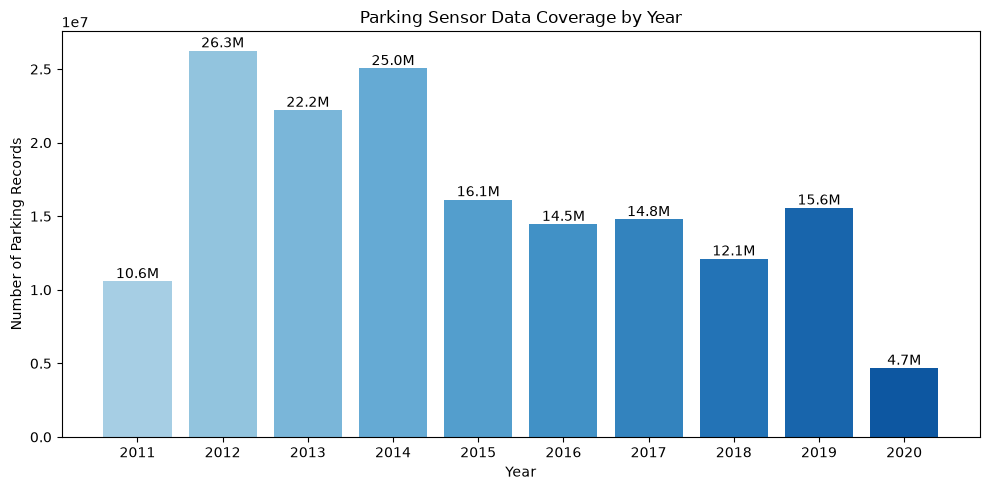

In [231]:
import matplotlib.pyplot as plt
import numpy as np

# Create gradient colours from light blue to dark blue
colors = plt.cm.Blues(
    np.linspace(0.35, 0.85, len(coverage_by_year))
)

# Create bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    coverage_by_year["source_year"],
    coverage_by_year["total_records"],
    color=colors
)

# Add the number of records above each bar
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

# Add chart title and axis labels
plt.title("Parking Sensor Data Coverage by Year")
plt.xlabel("Year")
plt.ylabel("Number of Parking Records")

# Display all years on the x-axis
plt.xticks(coverage_by_year["source_year"])

plt.tight_layout()
plt.show()

The number of parking sensor records varies across the years. The highest number of records is in 2012, with approximately 26 million records, while 2020 has the lowest number, with approximately 4.6 million records. The lower number of records in 2011 and 2020 may be affected by incomplete yearly data coverage. 

#### 1.2 Parking Sensor Data Coverage by Month
This analysis examines the number of parking sensor records available in each month across the years. It helps identify months with low or missing data and shows whether the data coverage is consistent over time.

In [209]:
# Get the number of parking records for each month
coverage_by_month = con.execute("""
    SELECT
        source_year,
        MONTH(arrival_time) AS month,
        COUNT(*) AS total_records,
        COUNT(DISTINCT street_name) AS unique_streets,
        COUNT(DISTINCT device_id) AS unique_sensors
    FROM parking_sensor_matched
    WHERE arrival_time IS NOT NULL
    GROUP BY
        source_year,
        MONTH(arrival_time)
    ORDER BY
        source_year,
        month
""").fetchdf()

coverage_by_month

,source_year,month,total_records,unique_streets,unique_sensors
0,2011,1,3153,3,51
1,2011,7,16458,1,61
2,2011,8,638248,7,882
3,2011,9,2240181,11,1418
4,2011,10,2840392,15,1684
...,...,...,...,...,...
103,2020,1,1247509,18,1261
104,2020,2,1205092,18,1280
105,2020,3,1088253,18,1290
106,2020,4,547664,18,1272


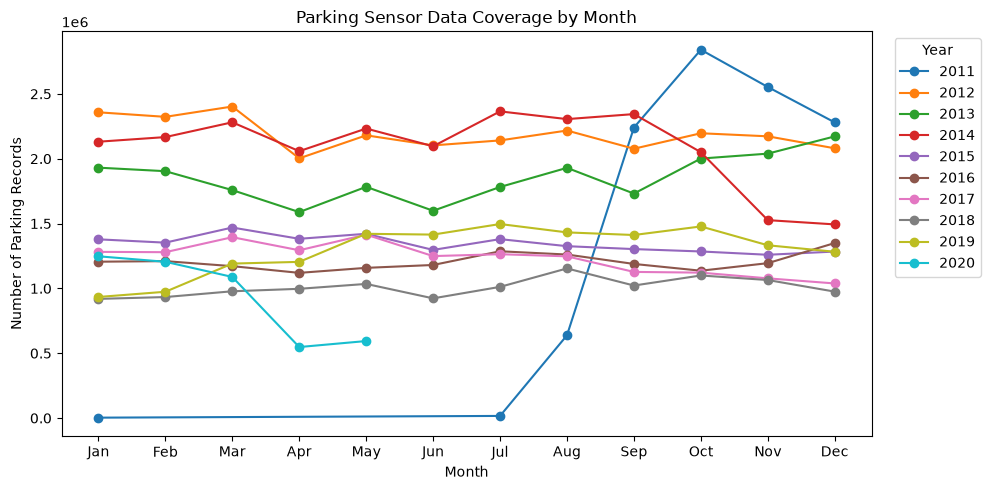

In [ ]:
# Create a monthly coverage line chart
plt.figure(figsize=(10, 5))

for year in sorted(coverage_by_month["source_year"].unique()):
    year_data = coverage_by_month[
        coverage_by_month["source_year"] == year
    ]

    plt.plot(
        year_data["month"],
        year_data["total_records"],
        marker="o",
        label=str(year)
    )

# Add chart title and axis labels
plt.title("Parking Sensor Data Coverage by Month")
plt.xlabel("Month")
plt.ylabel("Number of Parking Records")

# Display all months
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Monthly parking sensor coverage is not the same across all years. The 2011 data is available in January and from July to December, while the 2020 data is available only from January to May. The data from 2012 to 2019 covers all 12 months, although the number of parking records varies between months. 

#### 1.3 Street Coverage by Year
This analysis shows the number of project streets with parking sensor data in each year. It helps check whether the same streets are covered across the dataset before comparing parking patterns between years.

In [213]:
# Get parking sensor coverage for each street by year
street_coverage_year = con.execute("""
    SELECT
        street_name,
        source_year,
        COUNT(*) AS total_records
    FROM parking_sensor_matched
    WHERE street_name IS NOT NULL
    GROUP BY
        street_name,
        source_year
    ORDER BY
        street_name,
        source_year
""").fetchdf()

street_coverage_year

,street_name,source_year,total_records
0,ABBOTSFORD STREET,2011,1476
1,ABBOTSFORD STREET,2012,3993
2,ABBOTSFORD STREET,2013,2075
3,ALBERT STREET,2012,803059
4,ALBERT STREET,2013,1047657
...,...,...,...
175,WILLIAM STREET,2016,1152789
176,WILLIAM STREET,2017,1169507
177,WILLIAM STREET,2018,856169
178,WILLIAM STREET,2019,1122089


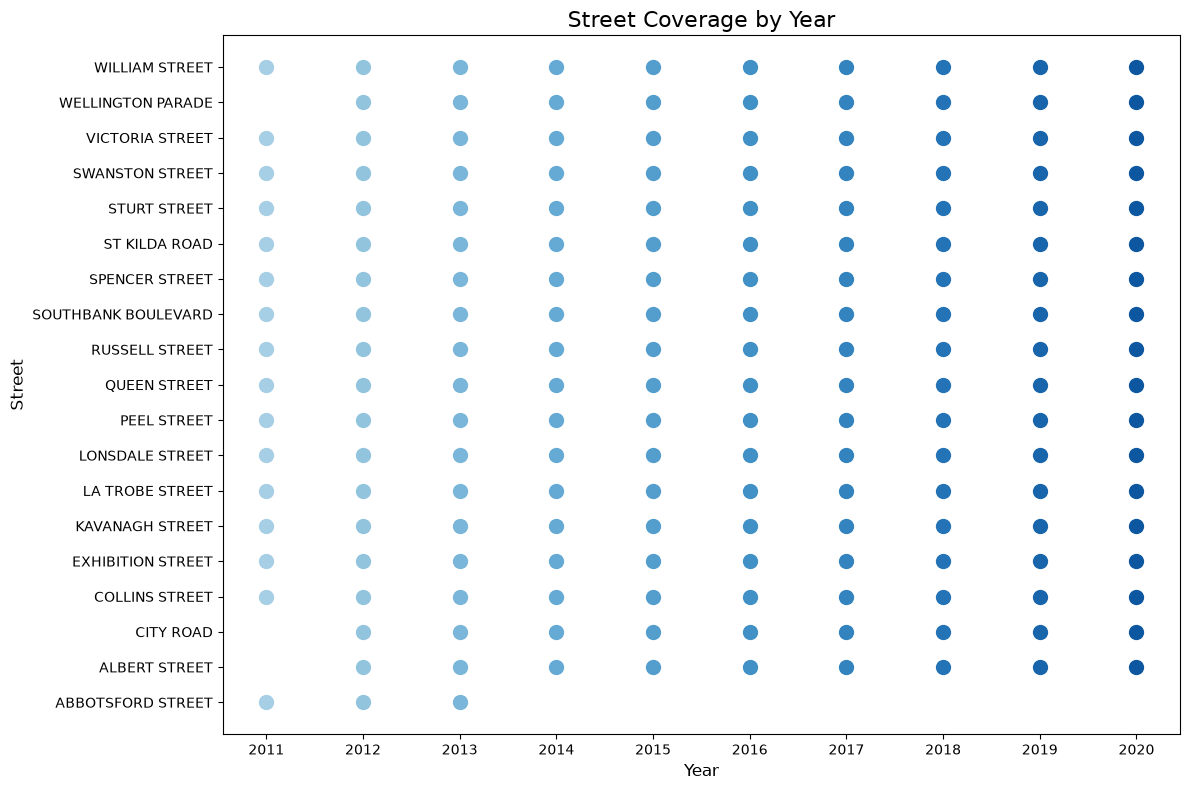

In [ ]:
# Get years and streets
years = sorted(street_coverage_year["source_year"].unique())
streets = sorted(street_coverage_year["street_name"].unique())

# Create gradient colours from light blue to dark blue
colors = plt.cm.Blues(
    np.linspace(0.35, 0.85, len(years))
)

# Create dot plot
plt.figure(figsize=(12, 8))

for i, year in enumerate(years):

    year_data = street_coverage_year[
        street_coverage_year["source_year"] == year
    ]

    # Get street positions
    y_positions = [
        streets.index(street)
        for street in year_data["street_name"]
    ]

    plt.scatter(
        [year] * len(year_data),
        y_positions,
        s=100,
        color=colors[i]
    )

# Add chart title and axis labels
plt.title("Street Coverage by Year", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Street", fontsize=12)

# Display all years and streets
plt.xticks(years)
plt.yticks(
    range(len(streets)),
    streets
)

plt.tight_layout()
plt.show()

Street coverage is not the same across all years. Most streets have parking sensor data from 2011 to 2020. Albert Street, City Road, and Wellington Parade have no data in 2011, while Abbotsford Street only has data from 2011 to 2013. This shows that most streets have good coverage across the study period, but some streets have missing years. 

#### 1.4 Street Monthly Coverage
This analysis checks the monthly data coverage for each project street. It helps identify streets with incomplete monthly data before comparing parking patterns across streets and time periods.

In [223]:
# Check the number of available months for each street and year
street_monthly_coverage = con.execute("""
    SELECT
        street_name,
        source_year,
        COUNT(DISTINCT MONTH(arrival_time)) AS available_months
    FROM parking_sensor_matched
    WHERE street_name IS NOT NULL
      AND arrival_time IS NOT NULL
    GROUP BY
        street_name,
        source_year
    ORDER BY
        street_name,
        source_year
""").fetchdf()

street_monthly_coverage

,street_name,source_year,available_months
0,ABBOTSFORD STREET,2011,3
1,ABBOTSFORD STREET,2012,10
2,ABBOTSFORD STREET,2013,6
3,ALBERT STREET,2012,8
4,ALBERT STREET,2013,12
...,...,...,...
175,WILLIAM STREET,2016,12
176,WILLIAM STREET,2017,12
177,WILLIAM STREET,2018,12
178,WILLIAM STREET,2019,12


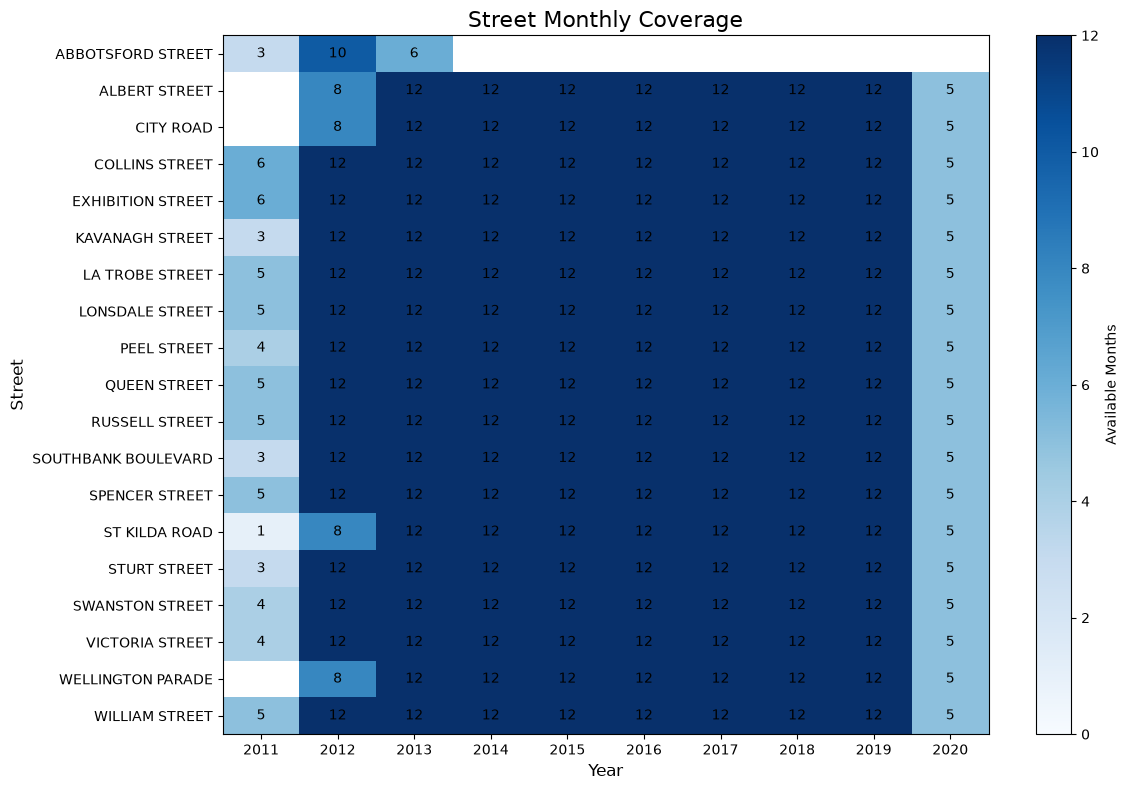

In [ ]:
# Convert the table to numeric values
data = street_month_table.values.astype(float)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))

heatmap = ax.imshow(
    data,
    cmap="Blues",
    vmin=0,
    vmax=12,
    aspect="auto"
)

# Add street names
ax.set_yticks(range(len(street_month_table.index)))
ax.set_yticklabels(street_month_table.index)

# Add years
ax.set_xticks(range(len(street_month_table.columns)))
ax.set_xticklabels(street_month_table.columns)

# Add number of available months to each cell
for i in range(data.shape[0]):
    for j in range(data.shape[1]):

        if not np.isnan(data[i, j]):
            ax.text(
                j,
                i,
                f"{int(data[i, j])}",
                ha="center",
                va="center"
            )

# Add colour bar
cbar = plt.colorbar(heatmap)
cbar.set_label("Available Months")

# Add title and labels
plt.title("Street Monthly Coverage", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Street", fontsize=12)

plt.tight_layout()
plt.show()

Monthly data coverage varies across streets and years. In 2011, the coverage is limited, with only 1 to 6 months of data available for most streets. In 2012, coverage improves, with most streets having 12 months of data, while some streets have 8 or 10 months. From 2013 to 2019, most streets have complete 12-month coverage. However, Abbotsford Street has only 6 months of data in 2013 and no data from 2014 onwards. In 2020, all available streets have only 5 months of data. 

### 2. Parking Duration & Temporal Patterns

#### 2.1 Parking Duration Distribution
This analysis examines how long vehicles are parked across the project streets. It helps identify the typical parking duration and whether there are very short or long parking events in the dataset.

In [241]:
# Summarise parking duration
duration_summary = con.execute("""
    SELECT
        COUNT(*) AS total_events,
        ROUND(AVG(duration_seconds) / 60, 2) AS mean_minutes,
        ROUND(MEDIAN(duration_seconds) / 60, 2) AS median_minutes,
        ROUND(MIN(duration_seconds) / 60, 2) AS min_minutes,
        ROUND(MAX(duration_seconds) / 60, 2) AS max_minutes
    FROM parking_sensor_matched
    WHERE duration_seconds > 0
""").fetchdf()

duration_summary

,total_events,mean_minutes,median_minutes,min_minutes,max_minutes
0,161842106,30.75,4.18,0.02,287576.37


In [242]:
# Group parking events into duration ranges
duration_distribution = con.execute("""
    SELECT
        CASE
            WHEN duration_seconds <= 15 * 60 THEN '0–15 min'
            WHEN duration_seconds <= 30 * 60 THEN '15–30 min'
            WHEN duration_seconds <= 60 * 60 THEN '30–60 min'
            WHEN duration_seconds <= 120 * 60 THEN '1–2 hours'
            WHEN duration_seconds <= 240 * 60 THEN '2–4 hours'
            ELSE '4+ hours'
        END AS duration_range,
        COUNT(*) AS parking_events
    FROM parking_sensor_matched
    WHERE duration_seconds > 0
    GROUP BY duration_range
""").fetchdf()

duration_distribution

,duration_range,parking_events
0,30–60 min,15306897
1,4+ hours,3991083
2,0–15 min,108991813
3,1–2 hours,12515626
4,2–4 hours,6114740
5,15–30 min,14921947


In [243]:
# Set duration range order
duration_order = [
    "0–15 min",
    "15–30 min",
    "30–60 min",
    "1–2 hours",
    "2–4 hours",
    "4+ hours"
]

duration_distribution["duration_range"] = pd.Categorical(
    duration_distribution["duration_range"],
    categories=duration_order,
    ordered=True
)

duration_distribution = (
    duration_distribution
    .sort_values("duration_range")
    .reset_index(drop=True)
)

duration_distribution

,duration_range,parking_events
0,0–15 min,108991813
1,15–30 min,14921947
2,30–60 min,15306897
3,1–2 hours,12515626
4,2–4 hours,6114740
5,4+ hours,3991083


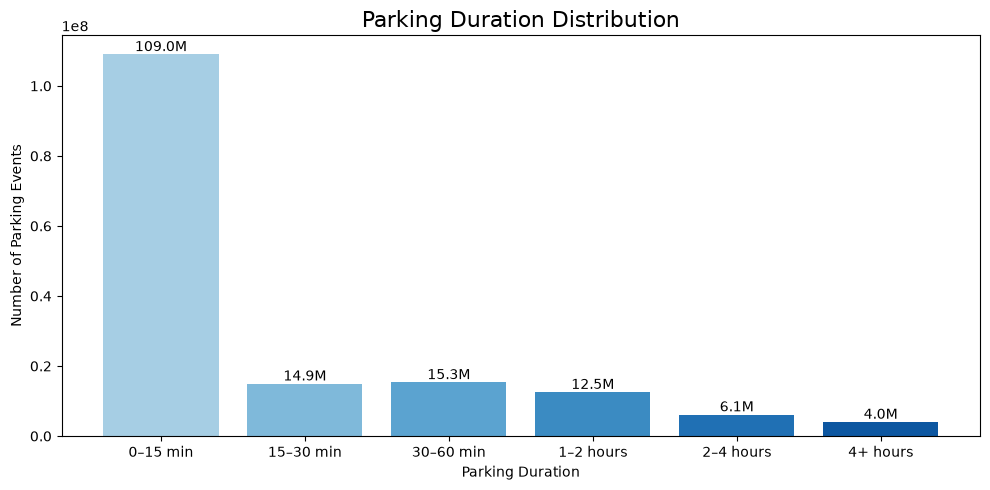

In [ ]:
# Create gradient colours from light blue to dark blue
colors = plt.cm.Blues(
    np.linspace(0.35, 0.85, len(duration_distribution))
)

# Create bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    duration_distribution["duration_range"],
    duration_distribution["parking_events"],
    color=colors
)

# Add values above each bar
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

# Add title and labels
plt.title("Parking Duration Distribution", fontsize=16)
plt.xlabel("Parking Duration")
plt.ylabel("Number of Parking Events")

plt.tight_layout()
plt.show()

Most parking events have a short parking duration. Around 109 million parking events are 15 minutes or less, which is much higher than the other duration groups. The number of parking events generally decreases as parking duration increases. Only around 4 million parking events last more than 4 hours. 

#### 2.2 Median Parking Duration by Street x Year
This analysis compares the median parking duration for each project street across different years. It helps identify changes in parking behaviour over time and highlights streets with noticeable changes that can be investigated further with the intervention timeline.

In [258]:
# Calculate median parking duration for each street and year
median_duration_street_year = con.execute("""
    SELECT
        street_name,
        source_year,
        COUNT(*) AS total_events,
        ROUND(MEDIAN(duration_seconds) / 60, 2) AS median_duration_minutes
    FROM parking_sensor_matched
    WHERE duration_seconds > 0
      AND street_name IS NOT NULL
    GROUP BY
        street_name,
        source_year
    ORDER BY
        street_name,
        source_year
""").fetchdf()

median_duration_street_year

,street_name,source_year,total_events,median_duration_minutes
0,ABBOTSFORD STREET,2011,1476,10.73
1,ABBOTSFORD STREET,2012,3993,9.87
2,ABBOTSFORD STREET,2013,2075,10.45
3,ALBERT STREET,2012,803059,1.82
4,ALBERT STREET,2013,1047657,1.77
...,...,...,...,...
175,WILLIAM STREET,2016,1152789,17.15
176,WILLIAM STREET,2017,1169507,18.45
177,WILLIAM STREET,2018,856169,20.00
178,WILLIAM STREET,2019,1122089,14.00


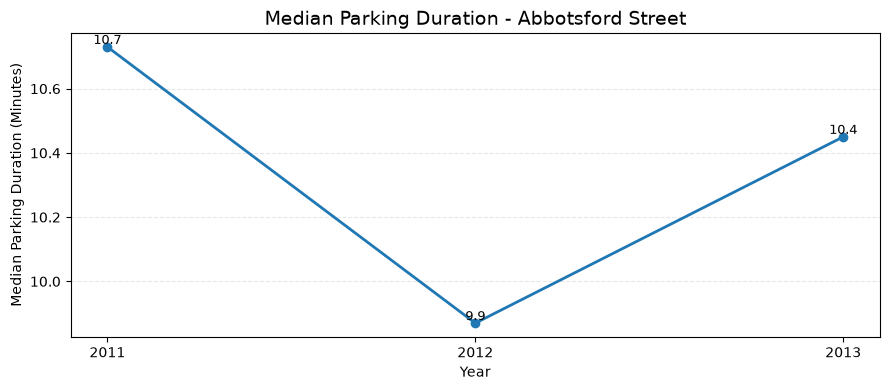

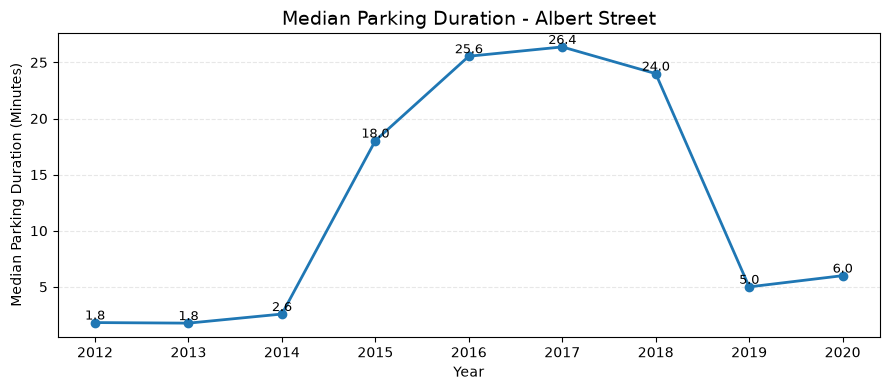

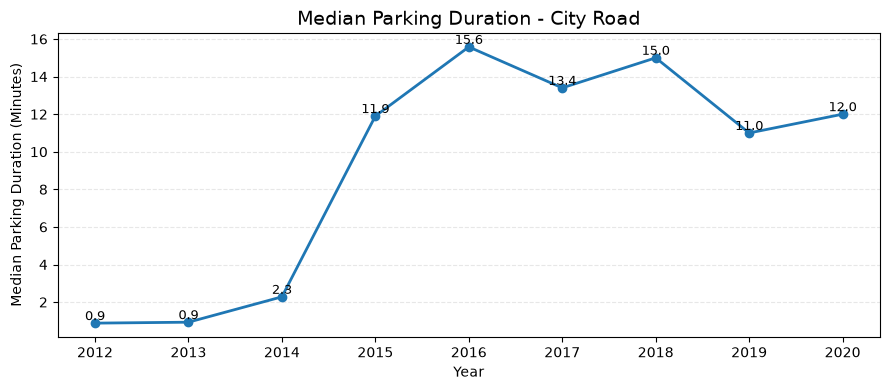

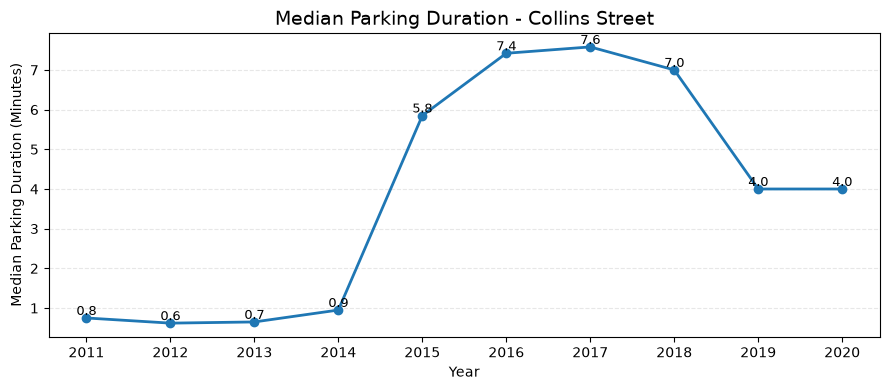

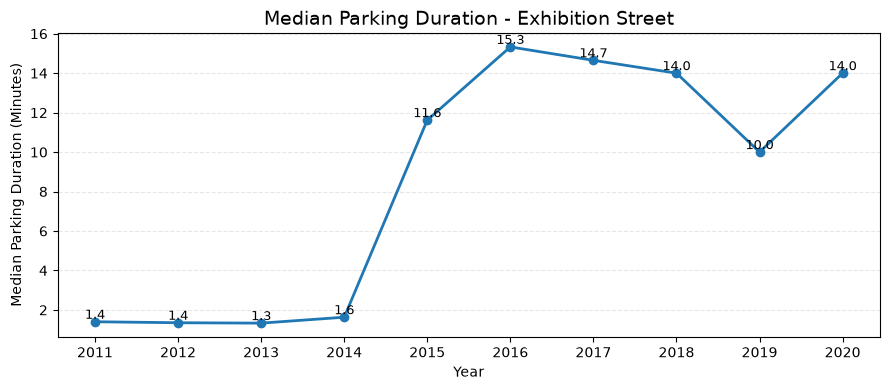

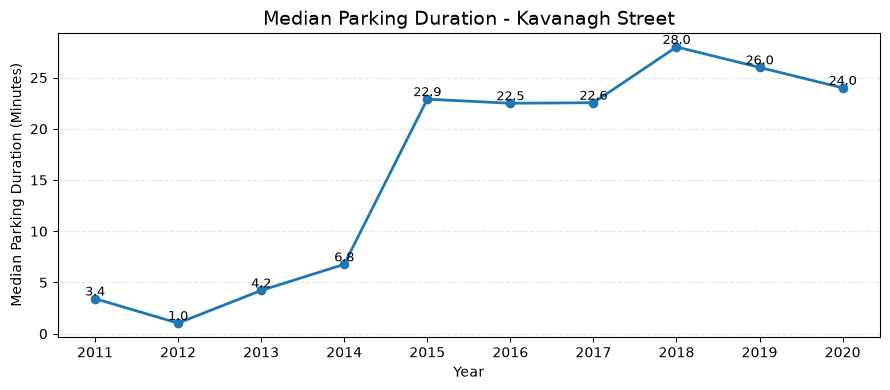

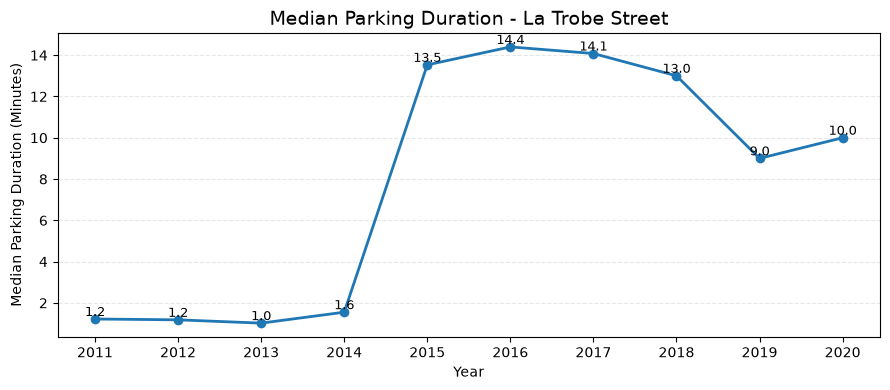

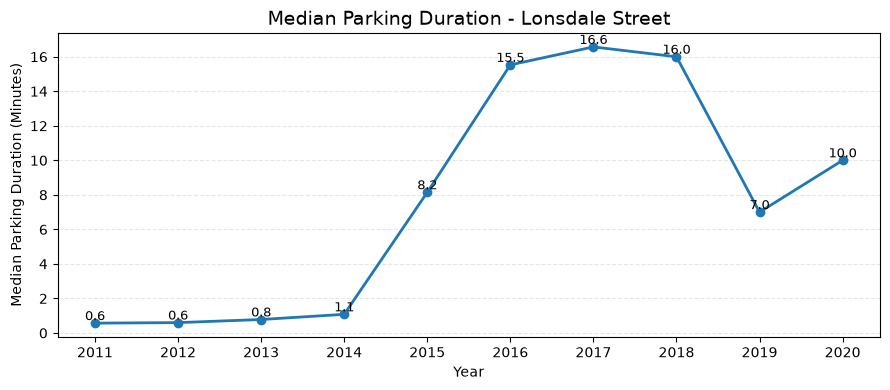

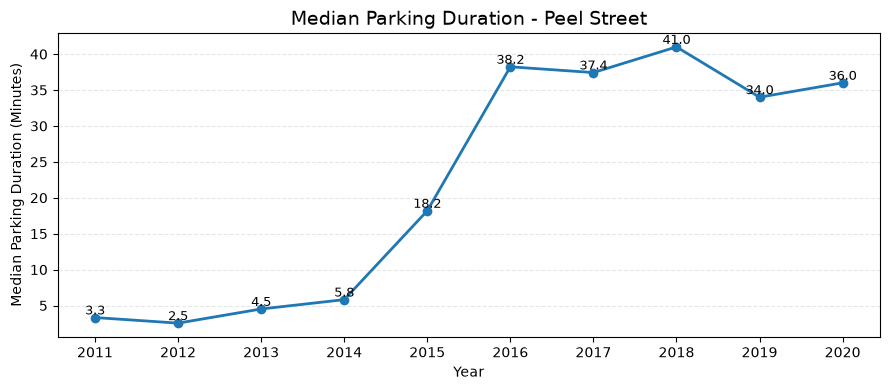

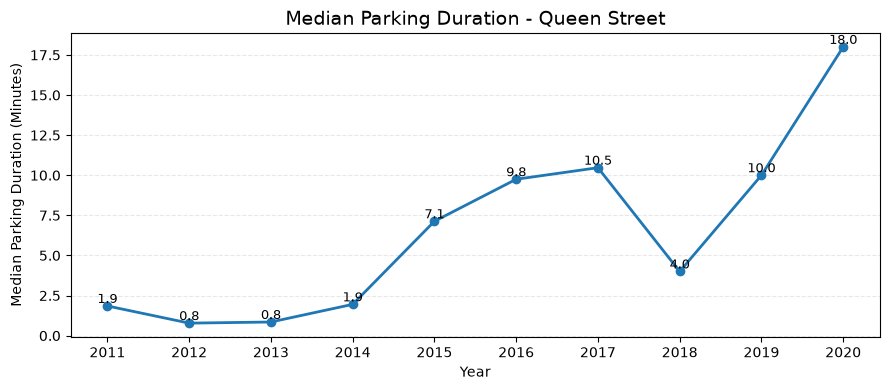

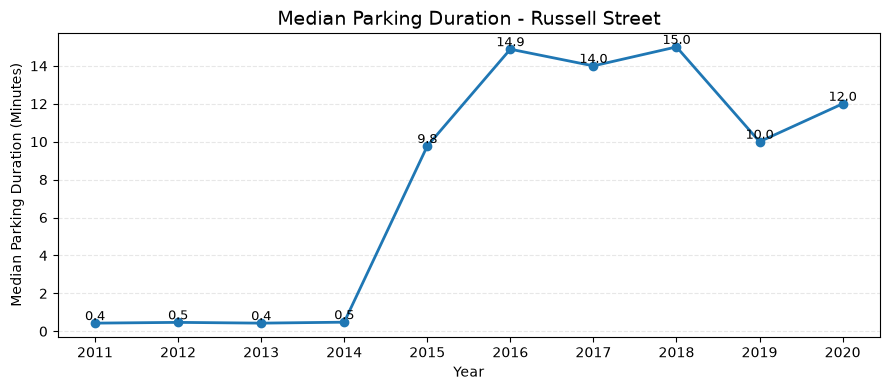

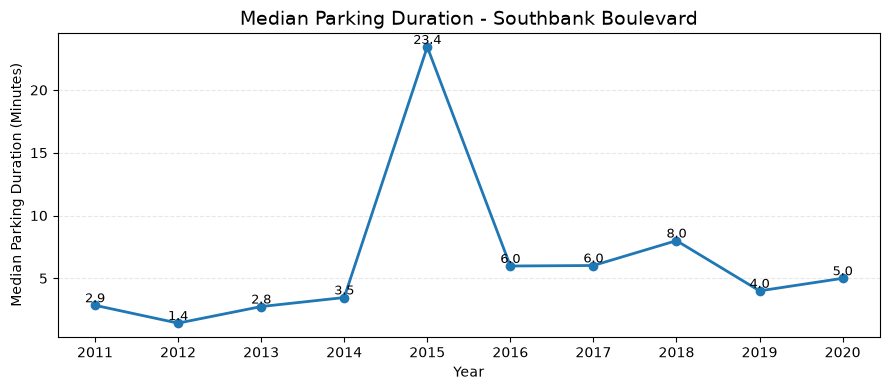

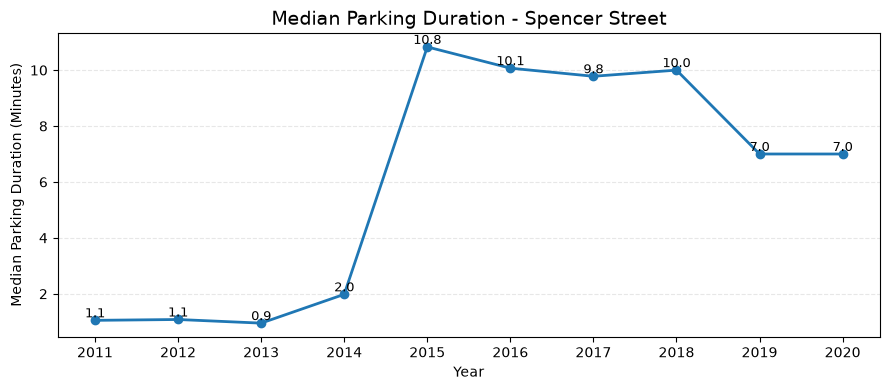

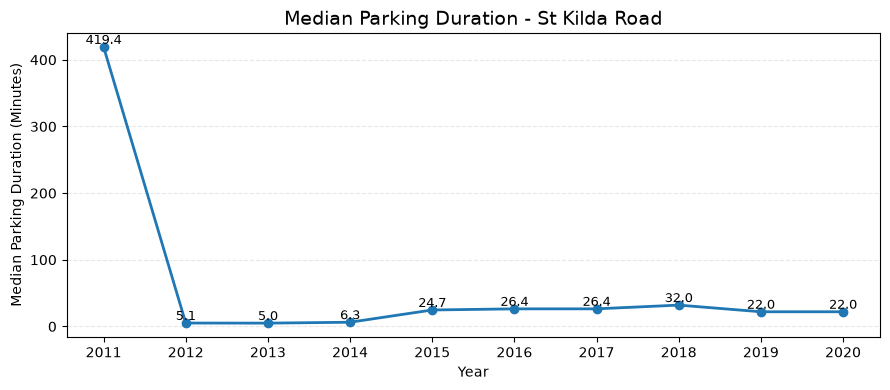

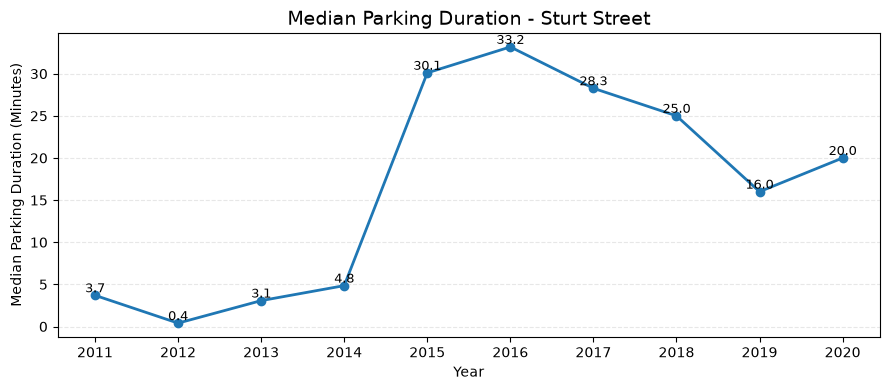

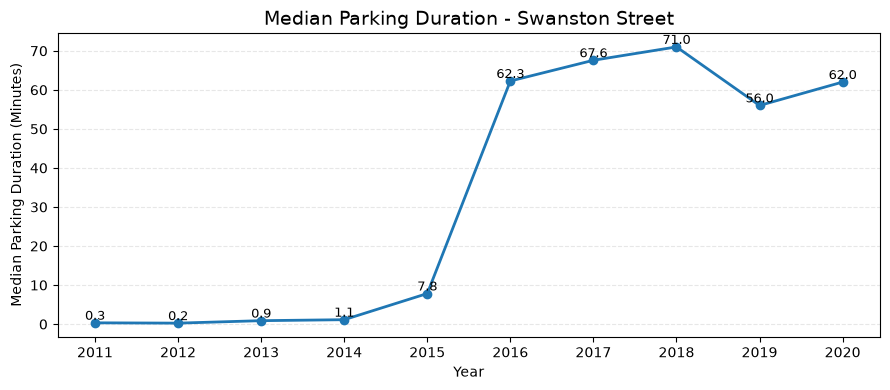

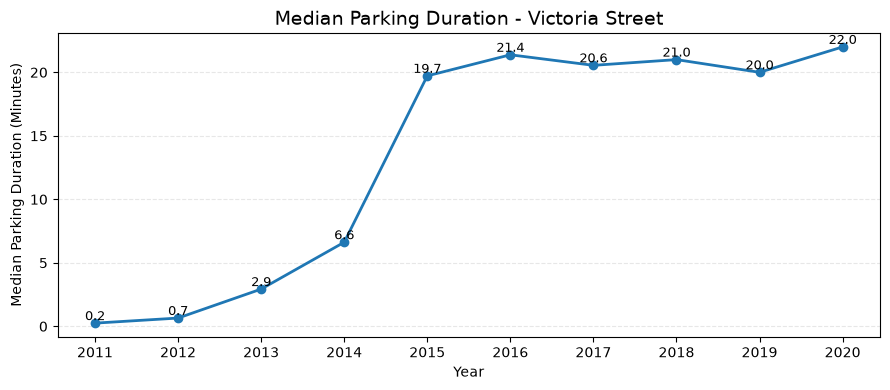

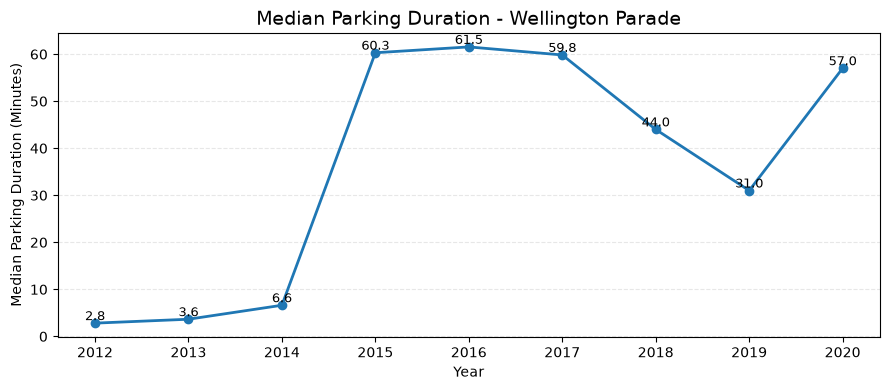

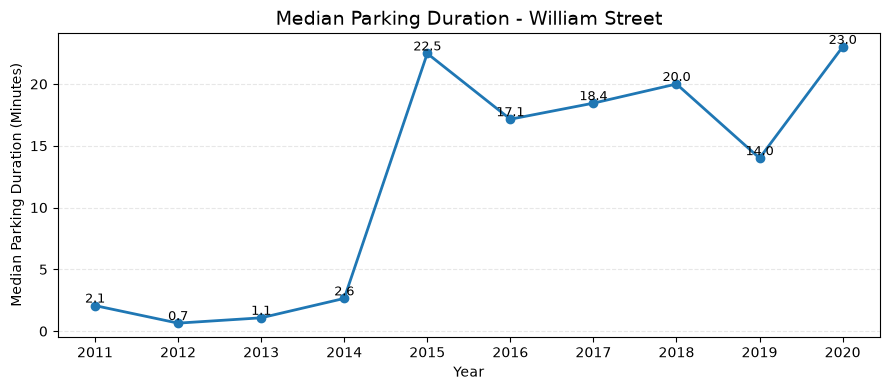

In [261]:
# Get all street names
streets = sorted(
    median_duration_street_year["street_name"].unique()
)

# Create one chart for each street
for street in streets:

    street_data = median_duration_street_year[
        median_duration_street_year["street_name"] == street
    ].sort_values("source_year")

    plt.figure(figsize=(9, 4))

    # Create line chart
    plt.plot(
        street_data["source_year"],
        street_data["median_duration_minutes"],
        marker="o",
        linewidth=2
    )

    # Add median duration above each point
    for _, row in street_data.iterrows():
        plt.text(
            row["source_year"],
            row["median_duration_minutes"],
            f'{row["median_duration_minutes"]:.1f}',
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Add title and labels
    plt.title(
        f"Median Parking Duration - {street.title()}",
        fontsize=14
    )

    plt.xlabel("Year")
    plt.ylabel("Median Parking Duration (Minutes)")

    plt.xticks(street_data["source_year"])

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

The median parking duration changes over time and the pattern is different across streets. Several streets show large changes in particular years. These changes should be investigated further to understand whether they are related to street interventions, changes in parking conditions, or changes in the sensor data.

A common change can be seen around 2014–2015, when the median parking duration increased on many streets. Since this change occurred across several streets at a similar time, it should be checked before linking the change to a specific intervention.

##### Street-level Observations

- **Abbotsford Street:** The median parking duration remained relatively stable from 2011 to 2013, ranging from 9.9 to 10.7 minutes. Data is not available after 2013.

- **Albert Street:** The median increased from 2.6 minutes in 2014 to 18.0 minutes in 2015. It continued to increase to around 25–26 minutes in 2016–2017, before dropping from 24.0 minutes in 2018 to 5.0 minutes in 2019.

- **City Road:** The median increased from 2.3 minutes in 2014 to 11.9 minutes in 2015 and reached 15.6 minutes in 2016. It remained around 11–15 minutes afterwards.

- **Collins Street:** The median remained below 1 minute from 2011 to 2014, then increased to 5.8 minutes in 2015 and around 7 minutes during 2016–2018. It decreased to 4.0 minutes in 2019.

- **Exhibition Street:** The median remained around 1–2 minutes from 2011 to 2014, then increased to 11.6 minutes in 2015 and 15.3 minutes in 2016. It decreased to 10.0 minutes in 2019 before increasing to 14.0 minutes in 2020.

- **Kavanagh Street:** The median increased from 6.8 minutes in 2014 to 22.9 minutes in 2015. It remained around 22–28 minutes from 2015 onwards.

- **La Trobe Street:** The median remained around 1–2 minutes from 2011 to 2014, then increased to 13.5 minutes in 2015. It remained around 13–14 minutes until 2018 before decreasing to 9.0 minutes in 2019.

- **Lonsdale Street:** The median increased from 1.1 minutes in 2014 to 8.2 minutes in 2015 and 15.5 minutes in 2016. It remained around 16 minutes until 2018 before dropping to 7.0 minutes in 2019.

- **Peel Street:** The median increased from 5.8 minutes in 2014 to 18.2 minutes in 2015 and 38.2 minutes in 2016. It then remained relatively high at around 34–41 minutes.

- **Queen Street:** The median increased from 1.9 minutes in 2014 to 7.1 minutes in 2015 and around 10 minutes in 2016–2017. It dropped to 4.0 minutes in 2018 and later increased to 18.0 minutes in 2020.

- **Russell Street:** The median remained around 0.4–0.5 minutes from 2011 to 2014, then increased to 9.8 minutes in 2015 and around 14–15 minutes during 2016–2018. It decreased to 10.0 minutes in 2019.

- **Southbank Boulevard:** The median increased sharply from 3.5 minutes in 2014 to 23.4 minutes in 2015, then dropped to 6.0 minutes in 2016. The large change around 2015 should be investigated further.

- **Spencer Street:** The median increased from 2.0 minutes in 2014 to 10.8 minutes in 2015. It remained around 10 minutes until 2018 before decreasing to 7.0 minutes in 2019.

- **St Kilda Road:** The median was very high at 419.4 minutes in 2011 compared with 5.1 minutes in 2012. The 2011 value is unusual and should be investigated before interpretation.

- **Sturt Street:** The median increased from 4.8 minutes in 2014 to 30.1 minutes in 2015. It reached 33.2 minutes in 2016 and then gradually decreased.

- **Swanston Street:** The median increased from 7.8 minutes in 2015 to 62.3 minutes in 2016. It remained high afterwards, ranging from 56 to 71 minutes.

- **Victoria Street:** The median increased gradually from 0.2 minutes in 2011 to 6.6 minutes in 2014, followed by a larger increase to 19.7 minutes in 2015. It then remained relatively stable at around 20–22 minutes.

- **Wellington Parade:** The median increased from 6.6 minutes in 2014 to 60.3 minutes in 2015. It remained around 60 minutes until 2017, decreased to 31.0 minutes in 2019, and increased again to 57.0 minutes in 2020.

- **William Street:** The median increased from 2.6 minutes in 2014 to 22.5 minutes in 2015. It remained between approximately 14 and 23 minutes afterwards.

##### Key Changes for Further Investigation

Several streets show large changes in median parking duration between years. These periods should be investigated further using the intervention and construction information and maps to check whether the changes may be related to changes on the street.

- **Albert Street:** 2014–2015 increased from 2.6 to 18.0 minutes, and 2018–2019 decreased from 24.0 to 5.0 minutes.

- **City Road:** 2014–2015 increased from 2.3 to 11.9 minutes.

- **Collins Street:** 2014–2015 increased from 0.9 to 5.8 minutes.

- **Exhibition Street:** 2014–2015 increased from 1.6 to 11.6 minutes.

- **Kavanagh Street:** 2014–2015 increased from 6.8 to 22.9 minutes.

- **La Trobe Street:** 2014–2015 increased from 1.6 to 13.5 minutes.

- **Lonsdale Street:** 2014–2016 increased from 1.1 to 15.5 minutes, and 2018–2019 decreased from 16.0 to 7.0 minutes.

- **Peel Street:** 2014–2016 increased from 5.8 to 38.2 minutes.

- **Queen Street:** 2017–2018 decreased from 10.5 to 4.0 minutes, and 2019–2020 increased from 10.0 to 18.0 minutes.

- **Russell Street:** 2014–2015 increased from 0.5 to 9.8 minutes.

- **Southbank Boulevard:** 2014–2015 increased from 3.5 to 23.4 minutes, followed by a decrease to 6.0 minutes in 2016.

- **Spencer Street:** 2014–2015 increased from 2.0 to 10.8 minutes.

- **St Kilda Road:** 2011 has an unusually high median of 419.4 minutes compared with 5.1 minutes in 2012. This should first be checked for possible data or coverage issues.

- **Sturt Street:** 2014–2015 increased from 4.8 to 30.1 minutes.

- **Swanston Street:** 2015–2016 increased from 7.8 to 62.3 minutes.

- **Victoria Street:** 2014–2015 increased from 6.6 to 19.7 minutes.

- **Wellington Parade:** 2014–2015 increased from 6.6 to 60.3 minutes, and 2019–2020 increased from 31.0 to 57.0 minutes.

- **William Street:** 2014–2015 increased from 2.6 to 22.5 minutes.

A common increase can be seen around **2014–2015 across many streets**. Because the same pattern appears on multiple streets, this period should also be checked.

#### Additional Check: St Kilda Road 2011
The unusually high median parking duration on St Kilda Road in 2011 was checked to understand whether it represents the overall parking pattern for that year.

In [264]:
st_kilda_monthly = con.execute("""
    SELECT
        MONTH(arrival_time) AS month,
        COUNT(*) AS total_records,
        COUNT(DISTINCT device_id) AS unique_sensors,
        ROUND(MEDIAN(duration_seconds) / 60.0, 1) AS median_minutes
    FROM parking_sensor_matched
    WHERE UPPER(street_name) = 'ST KILDA ROAD'
      AND source_year = 2011
      AND duration_seconds > 0
    GROUP BY MONTH(arrival_time)
    ORDER BY month
""").fetchdf()

st_kilda_monthly

,month,total_records,unique_sensors,median_minutes
0,1,5,5,419.4


**St Kilda Road:** The median parking duration in 2011 is 419.4 minutes, which is much higher than other years. However, further investigation found that only 5 parking records from 5 sensors are available in January 2011. Therefore, the 2011 median is based on very limited data and should not be used to represent the parking pattern for the whole year.

####

### 3. Construction Period Data
This section loads the quarterly street segment dataset, which contains information about when each street segment was under construction. The construction information is used to identify the construction period for project streets and compare it with the parking sensor data.

In [287]:
# Find the quarterly street segment file
qtr_file = list(data_folder.glob("street_segment*.csv"))[0]

print(qtr_file)

../../../data/raw/street_segment_qtr_attributes(in).csv


In [ ]:
# Load quarterly street segment attributes
con.execute(f"""
CREATE OR REPLACE VIEW street_segment_qtr_attributes AS
SELECT *
FROM read_csv_auto(
    '{qtr_file}',
    header=True,
    all_varchar=True
)
""")

#### 3.1 Match Construction Periods with Project Streets
The quarterly street segment data is matched with the project street data using `street_segment_id`. Only records where `is_under_construction = 1` are selected. This identifies which project streets were under construction and the quarters when construction occurred.

In [302]:
# Match streets with construction periods
construction_periods = con.execute("""
SELECT
    s.street_name,
    s.street_segment_id,
    s.treatment_or_control,
    s.intervention_type,
    q.QUARTER,
    q.is_under_construction
FROM street_spatial s
JOIN street_segment_qtr_attributes q
    ON s.street_segment_id = q.STREET_SEGMENT_ID
WHERE q.is_under_construction = '1'
ORDER BY
    s.street_name,
    q.QUARTER
""").fetchdf()

construction_periods

,street_name,street_segment_id,treatment_or_control,intervention_type,QUARTER,is_under_construction
0,ABBOTSFORD STREET,1662,treatment,protected bike lane,1213Q4,1
1,ABBOTSFORD STREET,1663,treatment,protected bike lane,1213Q4,1
2,ABBOTSFORD STREET,1662,treatment,protected bike lane,1314Q1,1
3,ABBOTSFORD STREET,1663,treatment,protected bike lane,1314Q1,1
4,ABBOTSFORD STREET,1659,treatment,protected bike lane,2021Q1,1
...,...,...,...,...,...,...
184,WILLIAM STREET,11079,treatment,protected bike lane,1920Q2,1
185,WILLIAM STREET,11077,treatment,protected bike lane,2021Q1,1
186,WILLIAM STREET,11080,treatment,protected bike lane,2021Q1,1
187,WILLIAM STREET,11077,treatment,protected bike lane,2021Q2,1


#### 3.2 Match Construction Streets with Parking Sensor Data
The parking sensor dataset contains 19 project streets after the previous data preparation and street matching process. This section checks which of these streets also have construction period information. This is needed to identify streets that can be used for further parking analysis around the construction period.

In [303]:
# Get the 19 streets available in the parking sensor data
sensor_streets = con.execute("""
SELECT DISTINCT street_name
FROM parking_sensor_matched
ORDER BY street_name
""").fetchdf()

# Keep only construction periods for the matched sensor streets
construction_matched = construction_periods[
    construction_periods["street_name"].str.upper().str.strip().isin(
        sensor_streets["street_name"].str.upper().str.strip()
    )
].copy()

construction_matched

,street_name,street_segment_id,treatment_or_control,intervention_type,QUARTER,is_under_construction
0,ABBOTSFORD STREET,1662,treatment,protected bike lane,1213Q4,1
1,ABBOTSFORD STREET,1663,treatment,protected bike lane,1213Q4,1
2,ABBOTSFORD STREET,1662,treatment,protected bike lane,1314Q1,1
3,ABBOTSFORD STREET,1663,treatment,protected bike lane,1314Q1,1
4,ABBOTSFORD STREET,1659,treatment,protected bike lane,2021Q1,1
...,...,...,...,...,...,...
184,WILLIAM STREET,11079,treatment,protected bike lane,1920Q2,1
185,WILLIAM STREET,11077,treatment,protected bike lane,2021Q1,1
186,WILLIAM STREET,11080,treatment,protected bike lane,2021Q1,1
187,WILLIAM STREET,11077,treatment,protected bike lane,2021Q2,1


#### 3.3 Review Construction Periods
The construction periods are summarised for each matched street. The first and last construction quarters are checked to understand the overall construction timeline. All individual construction quarters are also listed because some streets have more than one construction period. 

In [305]:
construction_matched["street_name"].unique()

<StringArray>
[  'ABBOTSFORD STREET',       'ALBERT STREET',   'EXHIBITION STREET',
     'KAVANAGH STREET',     'LA TROBE STREET',         'PEEL STREET',
 'SOUTHBANK BOULEVARD',       'ST KILDA ROAD',     'SWANSTON STREET',
      'WILLIAM STREET']
Length: 10, dtype: str

In [309]:
# Summarise construction period for each street
construction_summary = (
    construction_details
    .groupby("street_name")
    .agg(
        first_construction_quarter=("QUARTER", "min"),
        last_construction_quarter=("QUARTER", "max")
    )
    .reset_index()
)

construction_summary

,street_name,first_construction_quarter,last_construction_quarter
0,ABBOTSFORD STREET,1213Q4,2021Q2
1,ALBERT STREET,0910Q4,1920Q4
2,EXHIBITION STREET,2021Q2,2122Q1
3,KAVANAGH STREET,2021Q4,2021Q4
4,LA TROBE STREET,1213Q3,1213Q4
5,PEEL STREET,2021Q3,2122Q1
6,SOUTHBANK BOULEVARD,1718Q4,2122Q4
7,ST KILDA ROAD,2223Q1,2324Q2
8,SWANSTON STREET,2021Q1,2021Q2
9,WILLIAM STREET,1920Q1,2021Q2


In [310]:
# List all construction quarters for each street
construction_quarters = (
    construction_details
    .groupby("street_name")["QUARTER"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .reset_index(name="construction_quarters")
)

construction_quarters

,street_name,construction_quarters
0,ABBOTSFORD STREET,"[1213Q4, 1314Q1, 2021Q1, 2021Q2]"
1,ALBERT STREET,"[0910Q4, 1011Q1, 1011Q2, 1011Q3, 1011Q4, 1718Q..."
2,EXHIBITION STREET,"[2021Q2, 2021Q3, 2021Q4, 2122Q1]"
3,KAVANAGH STREET,[2021Q4]
4,LA TROBE STREET,"[1213Q3, 1213Q4]"
5,PEEL STREET,"[2021Q3, 2021Q4, 2122Q1]"
6,SOUTHBANK BOULEVARD,"[1718Q4, 1819Q1, 1819Q2, 1819Q3, 1819Q4, 1920Q..."
7,ST KILDA ROAD,"[2223Q1, 2223Q2, 2223Q3, 2223Q4, 2324Q1, 2324Q2]"
8,SWANSTON STREET,"[2021Q1, 2021Q2]"
9,WILLIAM STREET,"[1920Q1, 1920Q2, 2021Q1, 2021Q2]"


##### Selection of Streets for Quarterly Analysis

There are 19 project streets available in the matched parking sensor data, and 10 of these streets also have construction period information. The parking sensor dataset only covers the period from 2011 to 2020. Several of the matched streets have construction periods after the available sensor data, which means their parking conditions before and after construction cannot be compared using this dataset.

4 streets have suitable overlap between the parking sensor data and their construction periods: La Trobe Street, Albert Street, Southbank Boulevard, and William Street. These streets were therefore selected for the quarterly parking analysis.

#### 3.4 Quarterly Parking Analysis
The following analysis examines parking conditions for selected streets with both parking sensor data and construction period information. For each street, the median parking duration is calculated by calendar quarter and compared with the construction period. The number of active parking sensors is also checked because changes in sensor coverage may affect the parking duration results.

The construction quarters in the project dataset use financial-year quarter labels, so they are converted to calendar quarters before being compared with the parking sensor data.

#### 3.4.1 La Trobe Street

In [335]:
# Median parking duration by quarter - La Trobe Street
la_trobe_quarterly = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(*) AS parking_events,
    ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
FROM parking_sensor_matched
WHERE street_name = 'LA TROBE STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

la_trobe_quarterly

,year,quarter,parking_events,median_minutes
0,2011,1,65,15.1
1,2011,3,298165,1.5
2,2011,4,915361,1.2
3,2012,1,853263,0.9
4,2012,2,842430,1.2
5,2012,3,855146,1.4
6,2012,4,738952,1.3
7,2013,1,452706,1.3
8,2013,2,24899,1.6
9,2013,3,620,60.0


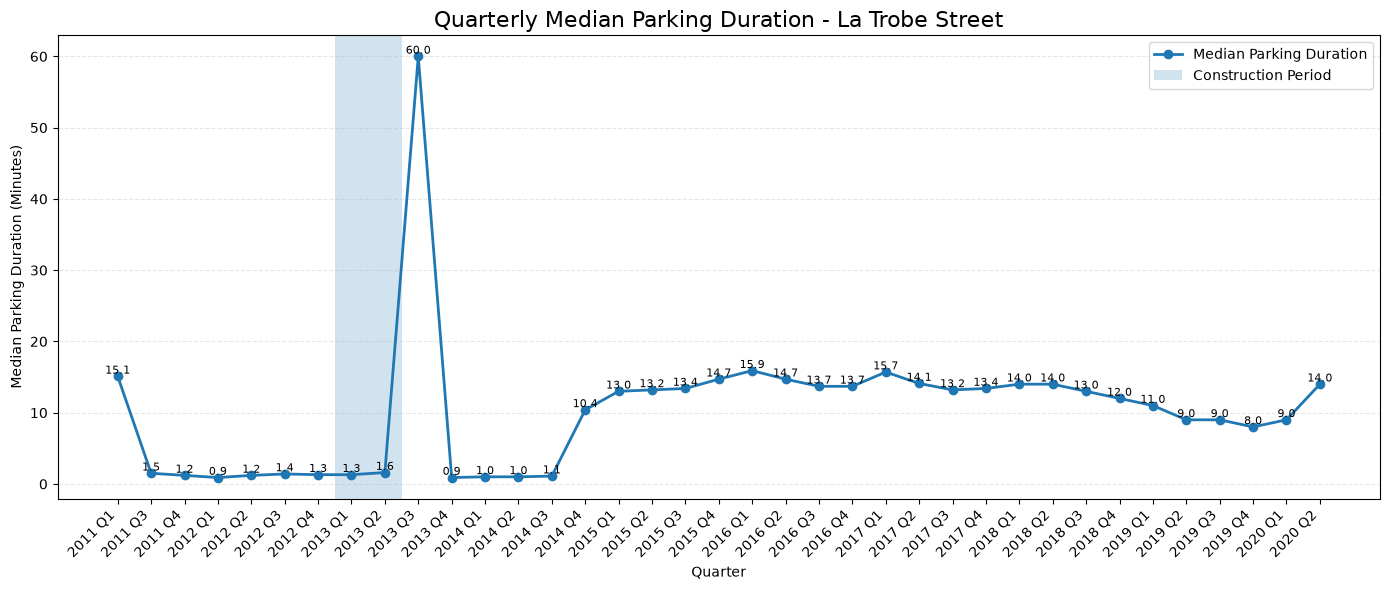

In [336]:
# Create quarter label
la_trobe_quarterly["period"] = (
    la_trobe_quarterly["year"].astype(int).astype(str)
    + " Q"
    + la_trobe_quarterly["quarter"].astype(int).astype(str)
)

# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

# Plot median parking duration
ax.plot(
    la_trobe_quarterly["period"],
    la_trobe_quarterly["median_minutes"],
    marker="o",
    linewidth=2,
    label="Median Parking Duration"
)

# Add median value above each point
for i, row in la_trobe_quarterly.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["median_minutes"],
        f'{row["median_minutes"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=8
    )

# Construction period from financial-year data:
# 1213Q3 = Jan-Mar 2013 = 2013 Q1
# 1213Q4 = Apr-Jun 2013 = 2013 Q2
periods = la_trobe_quarterly["period"].tolist()

construction_start = periods.index("2013 Q1")
construction_end = periods.index("2013 Q2")

# Highlight construction period
ax.axvspan(
    construction_start - 0.5,
    construction_end + 0.5,
    alpha=0.2,
    label="Construction Period"
)

# Add title and axis labels
ax.set_title(
    "Quarterly Median Parking Duration - La Trobe Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Median Parking Duration (Minutes)")

# Rotate quarter labels
plt.xticks(rotation=45, ha="right")

# Add grid and legend
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

In [325]:
# Count active sensors by quarter
la_trobe_sensor_coverage = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(DISTINCT device_id) AS number_of_sensors
FROM parking_sensor_matched
WHERE street_name = 'LA TROBE STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

# Create quarter label
la_trobe_sensor_coverage["period"] = (
    la_trobe_sensor_coverage["year"].astype(str)
    + " Q"
    + la_trobe_sensor_coverage["quarter"].astype(str)
)

la_trobe_sensor_coverage

,year,quarter,number_of_sensors,period
0,2011,1,3,2011 Q1
1,2011,3,250,2011 Q3
2,2011,4,251,2011 Q4
3,2012,1,288,2012 Q1
4,2012,2,303,2012 Q2
5,2012,3,276,2012 Q3
6,2012,4,280,2012 Q4
7,2013,1,247,2013 Q1
8,2013,2,56,2013 Q2
9,2013,3,35,2013 Q3


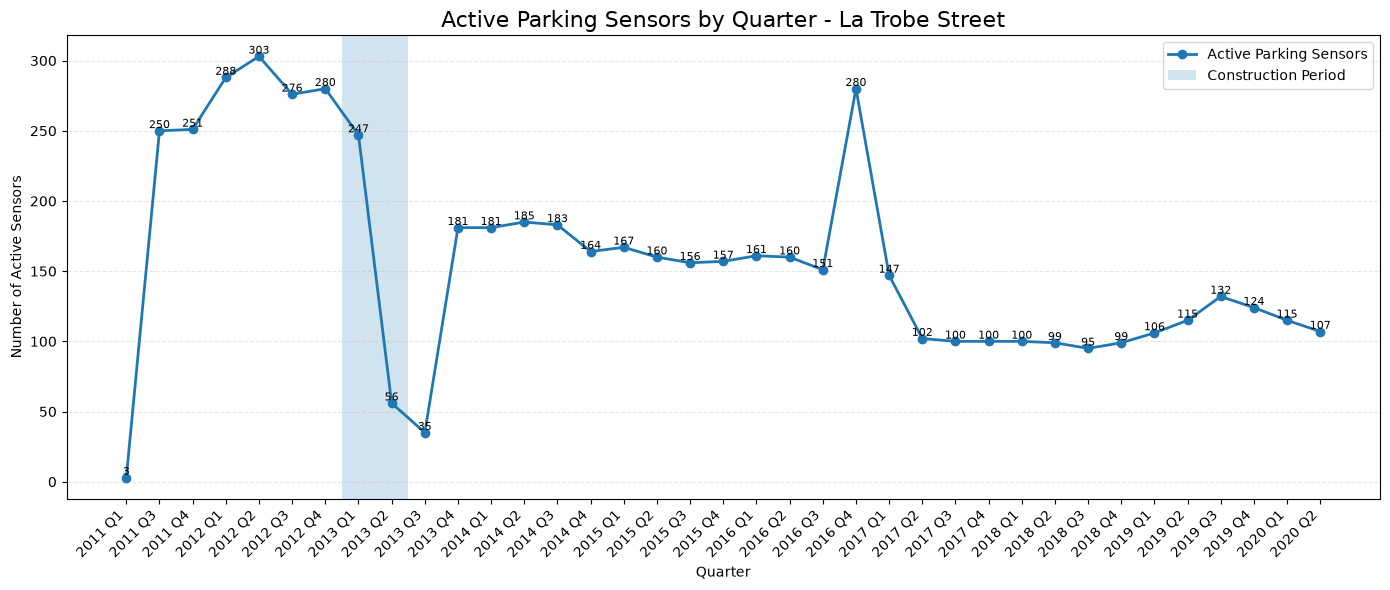

In [329]:
# Create quarter label
la_trobe_sensor_coverage["period"] = (
    la_trobe_sensor_coverage["year"].astype(str)
    + " Q"
    + la_trobe_sensor_coverage["quarter"].astype(str)
)

# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

# Plot number of active sensors
ax.plot(
    la_trobe_sensor_coverage["period"],
    la_trobe_sensor_coverage["number_of_sensors"],
    marker="o",
    linewidth=2,
    label="Active Parking Sensors"
)

# Add number of sensors above each point
for i, value in enumerate(
    la_trobe_sensor_coverage["number_of_sensors"]
):
    ax.text(
        i,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Construction period from financial-year data:
# 1213Q3 = Jan-Mar 2013 = 2013 Q1
# 1213Q4 = Apr-Jun 2013 = 2013 Q2
periods = la_trobe_sensor_coverage["period"].tolist()

construction_start = periods.index("2013 Q1")
construction_end = periods.index("2013 Q2")

# Highlight construction period
ax.axvspan(
    construction_start - 0.5,
    construction_end + 0.5,
    alpha=0.2,
    label="Construction Period"
)

# Add title and labels
ax.set_title(
    "Active Parking Sensors by Quarter - La Trobe Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Active Sensors")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

La Trobe Street was under construction during 2013 Q1–Q2. During this period, the number of active parking sensors decreased substantially, particularly in 2013 Q2. The median parking duration remained low during construction but increased unusually to 60 minutes in 2013 Q3. However, sensor coverage was much lower around this period, so this unusual increase may be affected by limited data and should not be interpreted as an intervention effect without further investigation.

#### 3.4.2 Albert Street

In [337]:
# Median parking duration by quarter - Albert Street
albert_quarterly = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(*) AS parking_events,
    ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
FROM parking_sensor_matched
WHERE street_name = 'ALBERT STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

albert_quarterly

,year,quarter,parking_events,median_minutes
0,2012,2,176548,1.8
1,2012,3,319086,1.9
2,2012,4,307425,1.8
3,2013,1,268539,1.8
4,2013,2,246644,1.8
5,2013,3,246467,1.8
6,2013,4,286007,1.7
7,2014,1,278511,1.8
8,2014,2,275217,1.6
9,2014,3,312312,1.5


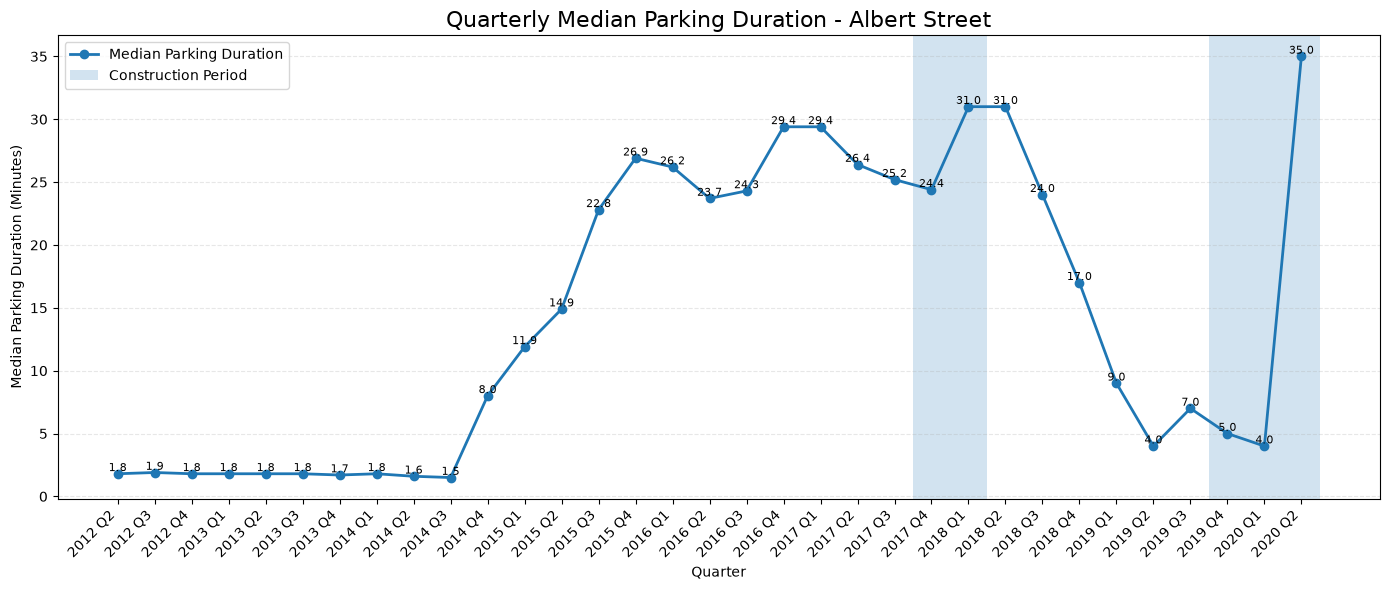

In [ ]:
# Create calendar quarter label
albert_quarterly["period"] = (
    albert_quarterly["year"].astype(int).astype(str)
    + " Q"
    + albert_quarterly["quarter"].astype(int).astype(str)
)

# Get all construction quarters for Albert Street
albert_construction_quarters = (
    construction_details[
        construction_details["street_name"] == "ALBERT STREET"
    ]["QUARTER"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Convert financial-year quarter to calendar quarter
# 1213Q1 -> 2012 Q3
# 1213Q2 -> 2012 Q4
# 1213Q3 -> 2013 Q1
# 1213Q4 -> 2013 Q2

def financial_to_calendar_quarter(fy_quarter):

    fy_quarter = str(fy_quarter)

    start_year = 2000 + int(fy_quarter[:2])
    end_year = 2000 + int(fy_quarter[2:4])
    q = int(fy_quarter[-1])

    if q == 1:
        return f"{start_year} Q3"

    elif q == 2:
        return f"{start_year} Q4"

    elif q == 3:
        return f"{end_year} Q1"

    elif q == 4:
        return f"{end_year} Q2"


construction_periods = [
    financial_to_calendar_quarter(q)
    for q in albert_construction_quarters
]


# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    albert_quarterly["period"],
    albert_quarterly["median_minutes"],
    marker="o",
    linewidth=2,
    label="Median Parking Duration"
)


# Highlight ALL construction quarters
periods = albert_quarterly["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Period" if not label_added else None
        )

        label_added = True


# Add median value above each point
for i, value in enumerate(albert_quarterly["median_minutes"]):

    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# Title and labels
ax.set_title(
    "Quarterly Median Parking Duration - Albert Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Median Parking Duration (Minutes)")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

In [342]:
# Active parking sensors by quarter - Albert Street
albert_sensor_coverage = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(DISTINCT device_id) AS number_of_sensors
FROM parking_sensor_matched
WHERE street_name = 'ALBERT STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

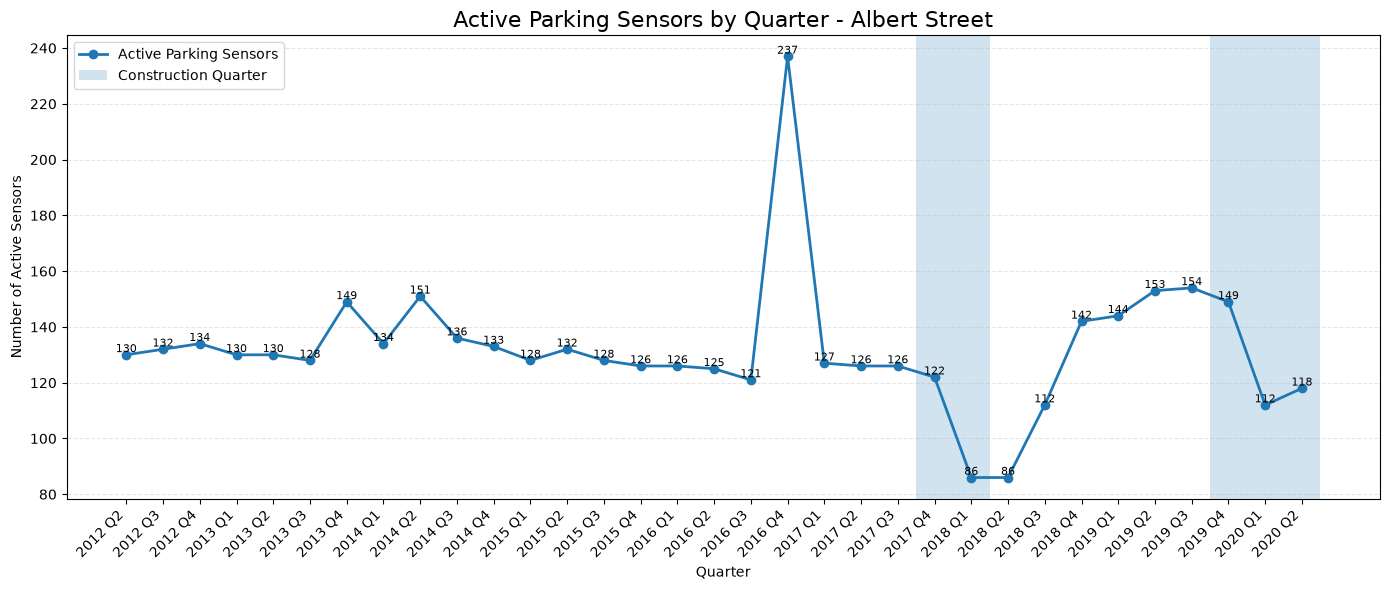

In [ ]:
# Create calendar quarter label
albert_sensor_coverage["period"] = (
    albert_sensor_coverage["year"].astype(int).astype(str)
    + " Q"
    + albert_sensor_coverage["quarter"].astype(int).astype(str)
)

# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    albert_sensor_coverage["period"],
    albert_sensor_coverage["number_of_sensors"],
    marker="o",
    linewidth=2,
    label="Active Parking Sensors"
)

# Highlight all construction quarters
periods = albert_sensor_coverage["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Quarter" if not label_added else None
        )
        label_added = True

# Add number of sensors above each point
for i, value in enumerate(
    albert_sensor_coverage["number_of_sensors"]
):
    ax.text(
        i,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Title and labels
ax.set_title(
    "Active Parking Sensors by Quarter - Albert Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Active Sensors")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

Albert Street was under construction during 2017 Q4–2018 Q2 and 2019 Q4–2020 Q2. During these periods, the number of active parking sensors decreased. The median parking duration increased during the first construction period and increased sharply to 35 minutes in 2020 Q2 during the second construction period. Changes in sensor coverage should also be considered when interpreting these parking duration patterns.

#### 3.4.3 Southbank Boulevard

In [344]:
# Calculate quarterly median parking duration
southbank_quarterly = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(*) AS parking_events,
    ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
FROM parking_sensor_matched
WHERE street_name = 'SOUTHBANK BOULEVARD'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

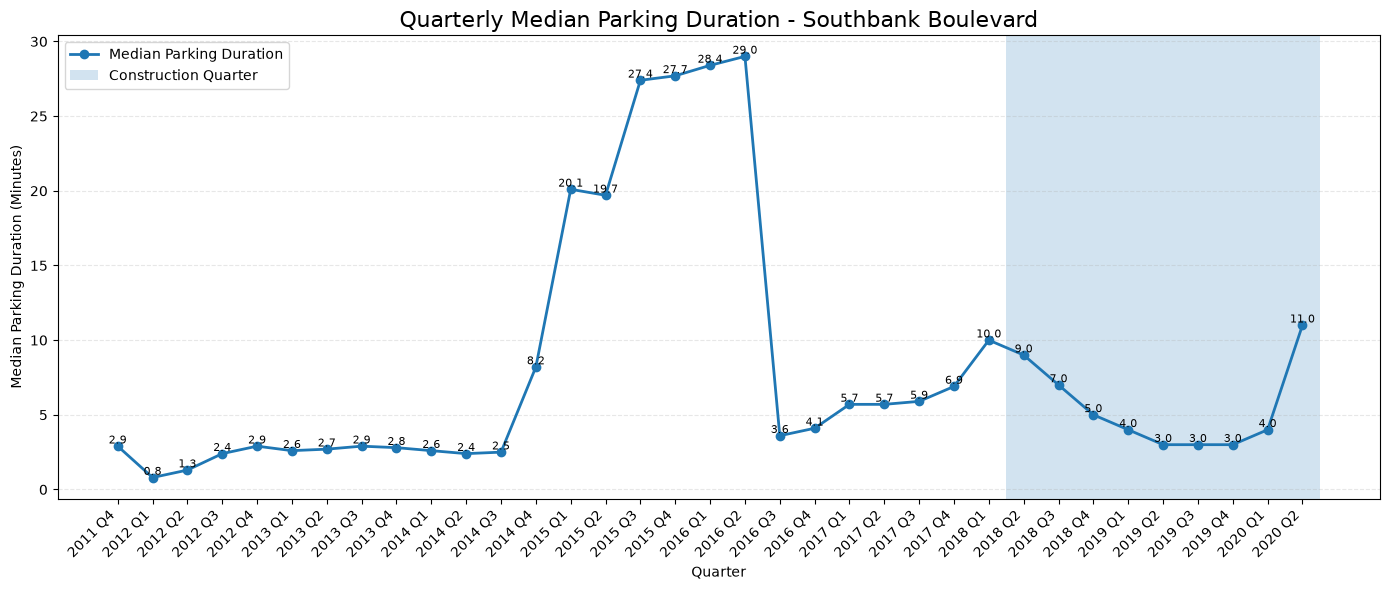

In [345]:
# Create calendar quarter label
southbank_quarterly["period"] = (
    southbank_quarterly["year"].astype(int).astype(str)
    + " Q"
    + southbank_quarterly["quarter"].astype(int).astype(str)
)


# Get all construction quarters for Southbank Boulevard
southbank_construction_quarters = (
    construction_details[
        construction_details["street_name"] == "SOUTHBANK BOULEVARD"
    ]["QUARTER"]
    .dropna()
    .drop_duplicates()
    .tolist()
)


# Convert financial-year quarter to calendar quarter
construction_periods = [
    financial_to_calendar_quarter(q)
    for q in southbank_construction_quarters
]


# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    southbank_quarterly["period"],
    southbank_quarterly["median_minutes"],
    marker="o",
    linewidth=2,
    label="Median Parking Duration"
)


# Highlight all construction quarters
periods = southbank_quarterly["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Quarter" if not label_added else None
        )

        label_added = True


# Add median values
for i, value in enumerate(southbank_quarterly["median_minutes"]):

    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# Title and labels
ax.set_title(
    "Quarterly Median Parking Duration - Southbank Boulevard",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Median Parking Duration (Minutes)")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

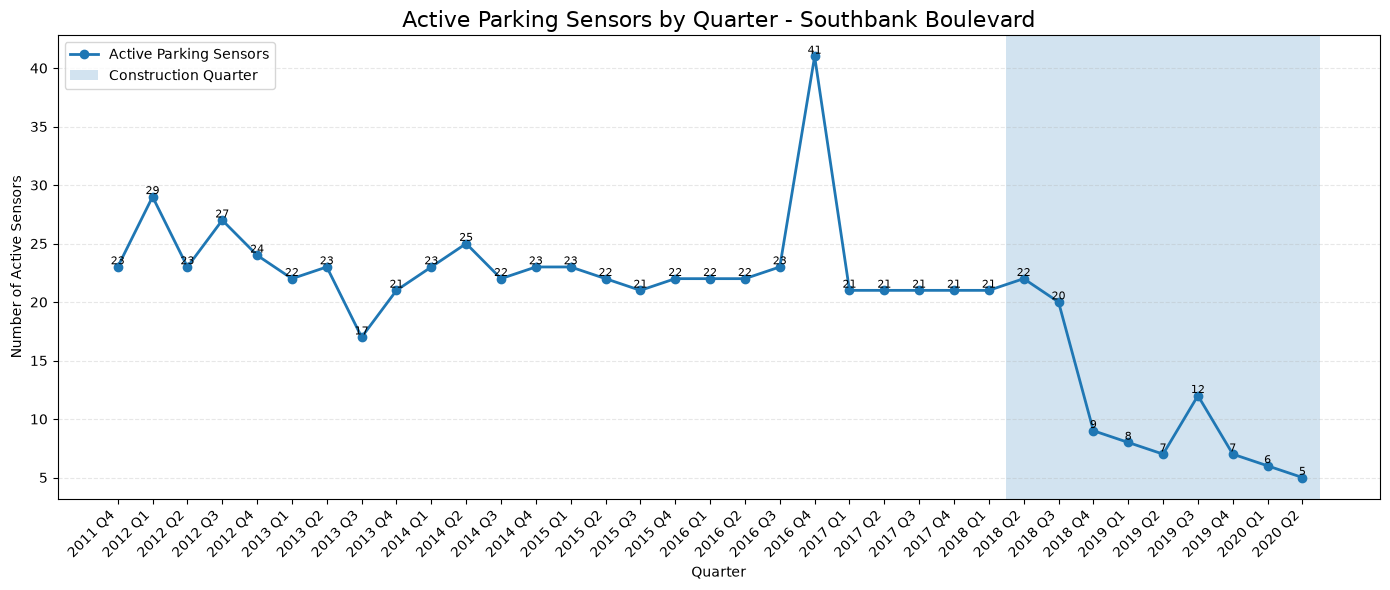

In [346]:
# Count active sensors by quarter
southbank_sensor_coverage = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(DISTINCT device_id) AS number_of_sensors
FROM parking_sensor_matched
WHERE street_name = 'SOUTHBANK BOULEVARD'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()


# Create calendar quarter label
southbank_sensor_coverage["period"] = (
    southbank_sensor_coverage["year"].astype(int).astype(str)
    + " Q"
    + southbank_sensor_coverage["quarter"].astype(int).astype(str)
)


# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    southbank_sensor_coverage["period"],
    southbank_sensor_coverage["number_of_sensors"],
    marker="o",
    linewidth=2,
    label="Active Parking Sensors"
)


# Highlight all construction quarters
periods = southbank_sensor_coverage["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Quarter" if not label_added else None
        )

        label_added = True


# Add number of sensors above each point
for i, value in enumerate(
    southbank_sensor_coverage["number_of_sensors"]
):
    ax.text(
        i,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=8
    )


# Title and labels
ax.set_title(
    "Active Parking Sensors by Quarter - Southbank Boulevard",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Active Sensors")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

Southbank Boulevard was under construction during 2018 Q2–2020 Q2. During this period, the median parking duration generally decreased from around 9 minutes to 3–4 minutes before increasing to 11 minutes in 2020 Q2. However, the number of active parking sensors also decreased substantially during the construction period, from around 20–22 sensors to only 5 sensors by 2020 Q2. Therefore, the change in parking duration may be affected by reduced sensor coverage and should not be interpreted as an intervention effect without further investigation.

#### 3.4.4 William Street

In [347]:
# Calculate quarterly median parking duration
william_quarterly = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(*) AS parking_events,
    ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
FROM parking_sensor_matched
WHERE street_name = 'WILLIAM STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()

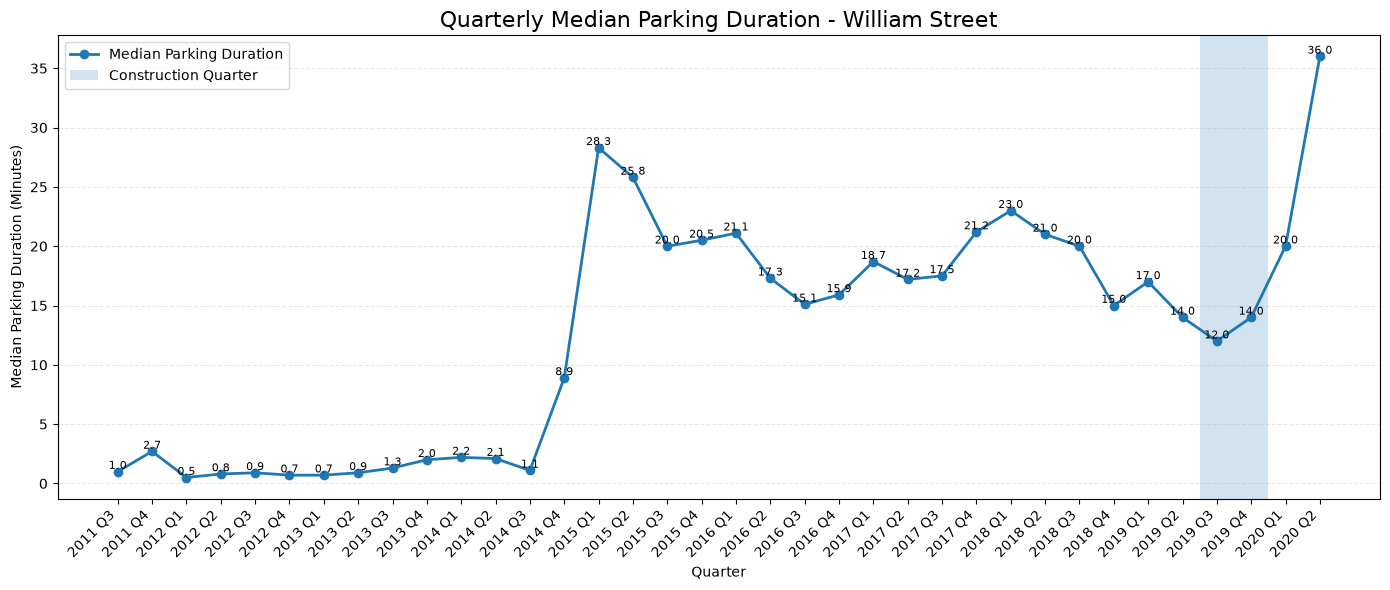

In [348]:
# Create calendar quarter label
william_quarterly["period"] = (
    william_quarterly["year"].astype(int).astype(str)
    + " Q"
    + william_quarterly["quarter"].astype(int).astype(str)
)

# Get all construction quarters for William Street
william_construction_quarters = (
    construction_details[
        construction_details["street_name"] == "WILLIAM STREET"
    ]["QUARTER"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

# Convert construction quarters to calendar quarters
construction_periods = [
    financial_to_calendar_quarter(q)
    for q in william_construction_quarters
]

# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    william_quarterly["period"],
    william_quarterly["median_minutes"],
    marker="o",
    linewidth=2,
    label="Median Parking Duration"
)

# Highlight all construction quarters
periods = william_quarterly["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Quarter" if not label_added else None
        )

        label_added = True

# Add median values
for i, value in enumerate(william_quarterly["median_minutes"]):

    ax.text(
        i,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Title and labels
ax.set_title(
    "Quarterly Median Parking Duration - William Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Median Parking Duration (Minutes)")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

In [349]:
# Count active sensors by quarter
william_sensor_coverage = con.execute("""
SELECT
    source_year AS year,
    QUARTER(arrival_time) AS quarter,
    COUNT(DISTINCT device_id) AS number_of_sensors
FROM parking_sensor_matched
WHERE street_name = 'WILLIAM STREET'
    AND duration_seconds > 0
GROUP BY
    source_year,
    QUARTER(arrival_time)
ORDER BY
    year,
    quarter
""").fetchdf()


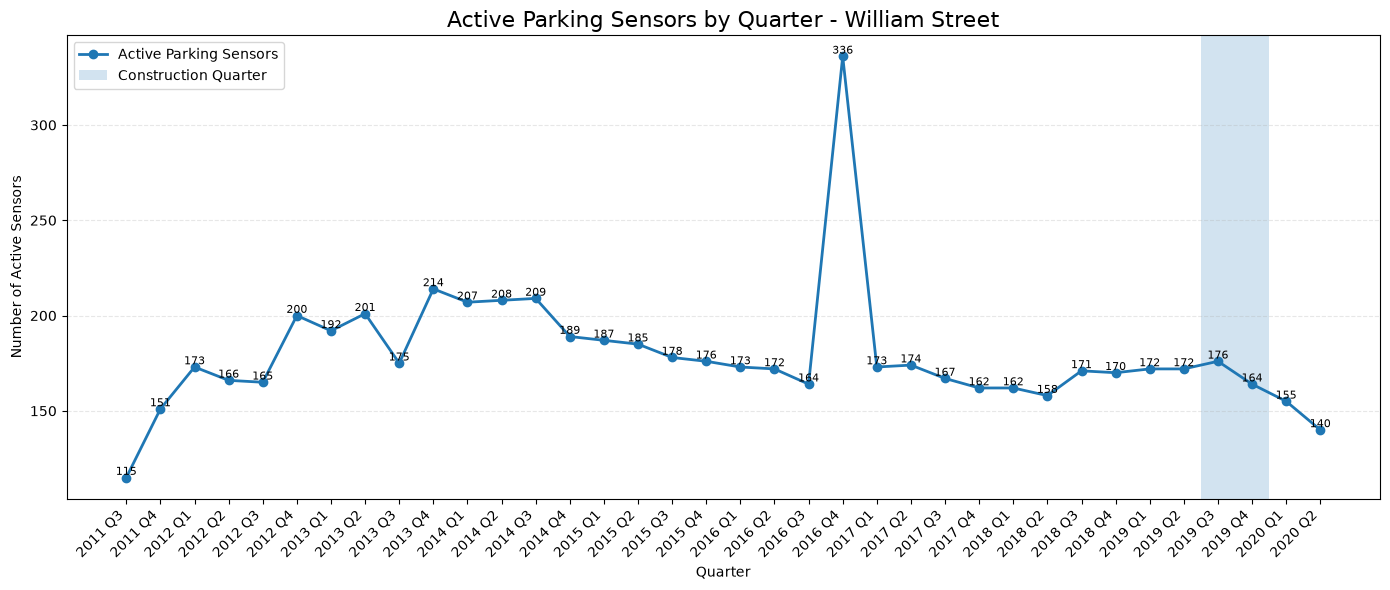

In [ ]:
# Create calendar quarter label
william_sensor_coverage["period"] = (
    william_sensor_coverage["year"].astype(int).astype(str)
    + " Q"
    + william_sensor_coverage["quarter"].astype(int).astype(str)
)

# Create graph
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    william_sensor_coverage["period"],
    william_sensor_coverage["number_of_sensors"],
    marker="o",
    linewidth=2,
    label="Active Parking Sensors"
)

# Highlight all construction quarters
periods = william_sensor_coverage["period"].tolist()

label_added = False

for construction_period in construction_periods:

    if construction_period in periods:

        position = periods.index(construction_period)

        ax.axvspan(
            position - 0.5,
            position + 0.5,
            alpha=0.2,
            label="Construction Quarter" if not label_added else None
        )

        label_added = True

# Add number of sensors above each point
for i, value in enumerate(
    william_sensor_coverage["number_of_sensors"]
):
    ax.text(
        i,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Title and labels
ax.set_title(
    "Active Parking Sensors by Quarter - William Street",
    fontsize=16
)

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Active Sensors")

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

William Street was under construction during 2019 Q3–Q4. During this period, the median parking duration decreased from around 14 minutes to 12 minutes. The number of active parking sensors also decreased from 176 before construction to 164 in 2019 Q4 and continued to decrease after construction. After the construction period, the median parking duration increased to 20 minutes in 2020 Q1 and 36 minutes in 2020 Q2. However, sensor coverage also continued to decrease during this period, so the increase in parking duration after construction should be interpreted with caution.

### 4. Before, During, and After Comparison Using Common Sensors

To make the comparison more consistent, only parking sensors that are available in all three periods are used. This helps reduce the effect of changes in sensor coverage between the Before, During, and After periods.

For each street:
1. Define the Before, During, and After construction periods.
2. Identify the active parking sensors in each period.
3. Find the common sensors that appear in all three periods.
4. Use only these common sensors to calculate the median parking duration for each period.

This method provides a more consistent comparison because the same group of parking sensors is used across all three periods. However, the number of parking records may still be different between periods.

#### 4.1 La Trobe Street

In [ ]:
# La Trobe Street comparison periods
la_trobe_periods = {
    "Before": [
        "2012 Q1", "2012 Q2", "2012 Q3", "2012 Q4"
    ],
    
    "During": [
        "2013 Q1", "2013 Q2"
    ],
    
    "After": [
        "2013 Q3", "2013 Q4", "2014 Q1", "2014 Q2"
    ]
}

In [365]:
# Get sensors for each period
def get_sensors(street, quarters):

    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    condition_sql = " OR ".join(conditions)

    sensors = con.execute(f"""
        SELECT DISTINCT device_id
        FROM parking_sensor_matched
        WHERE street_name = '{street}'
          AND duration_seconds > 0
          AND ({condition_sql})
    """).fetchdf()

    return set(sensors["device_id"])

In [371]:
la_before_sensors = get_sensors(
    "LA TROBE STREET",
    la_trobe_periods["Before"]
)

la_during_sensors = get_sensors(
    "LA TROBE STREET",
    la_trobe_periods["During"]
)

la_after_sensors = get_sensors(
    "LA TROBE STREET",
    la_trobe_periods["After"]
)

la_common_sensors = (
    la_before_sensors
    & la_during_sensors
    & la_after_sensors
)

print("Before sensors:", len(la_before_sensors))
print("During sensors:", len(la_during_sensors))
print("After sensors:", len(la_after_sensors))
print("Common sensors:", len(la_common_sensors))

Before sensors: 440
During sensors: 247
After sensors: 222
Common sensors: 32


In [ ]:
# Calculate parking duration using common sensors only
# First calculate median duration for each sensor,
# then calculate the median across all common sensors.

la_trobe_summary = []

# Convert common sensor IDs for SQL
sensor_list = ", ".join(
    [f"'{sensor}'" for sensor in la_common_sensors]
)

for period_name, quarters in la_trobe_periods.items():

    # Create quarter conditions
    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    # Calculate median for each sensor first
    result = con.execute(f"""
        WITH sensor_medians AS (
            SELECT
                device_id,
                MEDIAN(duration_seconds) / 60 AS sensor_median_minutes
            FROM parking_sensor_matched
            WHERE street_name = 'LA TROBE STREET'
              AND duration_seconds > 0
              AND device_id IN ({sensor_list})
              AND ({quarter_condition})
            GROUP BY device_id
        )

        SELECT
            ROUND(MEDIAN(sensor_median_minutes), 1) AS median_minutes,
            COUNT(*) AS sensors_used
        FROM sensor_medians
    """).fetchone()

    la_trobe_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": result[1]
    })

# Create summary table
la_trobe_summary = pd.DataFrame(la_trobe_summary)

# Add minutes label
la_trobe_summary["Median Parking Duration"] = (
    la_trobe_summary["Median Parking Duration"]
    .astype(str)
    + " min"
)

la_trobe_summary

,Period,Median Parking Duration,Common Sensors
0,Before,2.0 min,32
1,During,2.3 min,32
2,After,330.0 min,32


#### La Trobe Street Finding
La Trobe Street was under construction during 2013 Q1–Q2. The median parking duration using the 32 common sensors was 2.0 minutes before construction and 2.3 minutes during construction. After construction, the median increased substantially to 330.0 minutes. The same 32 sensors were used across all three periods, the difference is less likely to be caused by changes in sensor coverage.

#### 4.2 Albert Street

In [379]:
# Albert Street - Construction Period 1
albert_period1 = {
    "Before": [
        "2016 Q4", "2017 Q1", "2017 Q2", "2017 Q3"
    ],

    "During": [
        "2017 Q4", "2018 Q1"
    ],

    "After": [
        "2018 Q2", "2018 Q3", "2018 Q4", "2019 Q1"
    ]
}

In [381]:
# Get sensors for each period
albert1_before_sensors = get_sensors(
    "ALBERT STREET",
    albert_period1["Before"]
)

albert1_during_sensors = get_sensors(
    "ALBERT STREET",
    albert_period1["During"]
)

albert1_after_sensors = get_sensors(
    "ALBERT STREET",
    albert_period1["After"]
)

# Find common sensors
albert1_common_sensors = (
    albert1_before_sensors
    & albert1_during_sensors
    & albert1_after_sensors
)

print("Before sensors:", len(albert1_before_sensors))
print("During sensors:", len(albert1_during_sensors))
print("After sensors:", len(albert1_after_sensors))
print("Common sensors:", len(albert1_common_sensors))

Before sensors: 237
During sensors: 208
After sensors: 145
Common sensors: 0


In [383]:
print(
    "Before & During:",
    len(albert1_before_sensors & albert1_during_sensors)
)

print(
    "During & After:",
    len(albert1_during_sensors & albert1_after_sensors)
)

print(
    "Before & After:",
    len(albert1_before_sensors & albert1_after_sensors)
)

print(
    "All three:",
    len(
        albert1_before_sensors
        & albert1_during_sensors
        & albert1_after_sensors
    )
)

Before & During: 122
During & After: 86
Before & After: 0
All three: 0


Albert Street does not have the same sensors across the Before, During, and After periods. There are 122 common sensors between the Before and During periods and 86 common sensors between the During and After periods, but no common sensors between the Before and After periods.

Therefore, the analysis is separated into two comparisons:
1. Before vs During using 122 common sensors.
2. During vs After using 86 common sensors.

This allows each comparison to use the same set of sensors and reduces the effect of changes in sensor coverage.

In [384]:
# Common sensors between Before and During
albert_bd_common_sensors = (
    albert1_before_sensors
    & albert1_during_sensors
)

print("Common sensors:", len(albert_bd_common_sensors))

Common sensors: 122


In [385]:
# Compare Before and During using the same sensors
albert_bd_summary = []

albert_bd_periods = {
    "Before": albert_period1["Before"],
    "During": albert_period1["During"]
}

for period_name, quarters in albert_bd_periods.items():

    # Create quarter conditions
    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    # Common sensor IDs
    sensor_list = ", ".join(
        [f"'{sensor}'" for sensor in albert_bd_common_sensors]
    )

    # Calculate median parking duration
    result = con.execute(f"""
        SELECT
            ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
        FROM parking_sensor_matched
        WHERE street_name = 'ALBERT STREET'
          AND duration_seconds > 0
          AND device_id IN ({sensor_list})
          AND ({quarter_condition})
    """).fetchone()

    albert_bd_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": len(albert_bd_common_sensors)
    })

# Create summary table
albert_bd_summary = pd.DataFrame(albert_bd_summary)

albert_bd_summary["Median Parking Duration"] = (
    albert_bd_summary["Median Parking Duration"]
    .astype(str) + " min"
)

albert_bd_summary

,Period,Median Parking Duration,Common Sensors
0,Before,27.5 min,122
1,During,24.4 min,122


In [386]:
# Common sensors between During and After
albert_da_common_sensors = (
    albert1_during_sensors
    & albert1_after_sensors
)

print("Common sensors:", len(albert_da_common_sensors))

Common sensors: 86


In [387]:
# Compare During and After using the same sensors
albert_da_summary = []

albert_da_periods = {
    "During": albert_period1["During"],
    "After": albert_period1["After"]
}

for period_name, quarters in albert_da_periods.items():

    # Create quarter conditions
    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    # Common sensor IDs
    sensor_list = ", ".join(
        [f"'{sensor}'" for sensor in albert_da_common_sensors]
    )

    # Calculate median parking duration
    result = con.execute(f"""
        SELECT
            ROUND(MEDIAN(duration_seconds) / 60, 1) AS median_minutes
        FROM parking_sensor_matched
        WHERE street_name = 'ALBERT STREET'
          AND duration_seconds > 0
          AND device_id IN ({sensor_list})
          AND ({quarter_condition})
    """).fetchone()

    albert_da_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": len(albert_da_common_sensors)
    })

# Create summary table
albert_da_summary = pd.DataFrame(albert_da_summary)

albert_da_summary["Median Parking Duration"] = (
    albert_da_summary["Median Parking Duration"]
    .astype(str) + " min"
)

albert_da_summary

,Period,Median Parking Duration,Common Sensors
0,During,31.0 min,86
1,After,31.0 min,86


##### Albert Street Finding (1)

The median parking duration decreased slightly from 27.5 minutes before construction to 24.4 minutes during construction, using the same 122 parking sensors. This suggests a small decrease in parking duration during the construction period.

For the During and After comparison, the median parking duration remained the same at 31.0 minutes using the same 86 parking sensors. This suggests that there was no clear change in median parking duration between these two periods.

In [390]:
# Albert Street - Construction Period 2
albert_period2 = {
    "Before": [
        "2018 Q4", "2019 Q1", "2019 Q2", "2019 Q3"
    ],

    "During": [
        "2019 Q4", "2020 Q1", "2020 Q2"
    ]
}

In [391]:
# Get sensors for each period
albert2_before_sensors = get_sensors(
    "ALBERT STREET",
    albert_period2["Before"]
)

albert2_during_sensors = get_sensors(
    "ALBERT STREET",
    albert_period2["During"]
)

# Find common sensors between Before and During
albert2_common_sensors = (
    albert2_before_sensors
    & albert2_during_sensors
)

print("Before sensors:", len(albert2_before_sensors))
print("During sensors:", len(albert2_during_sensors))
print("Common sensors:", len(albert2_common_sensors))

Before sensors: 169
During sensors: 184
Common sensors: 142


In [393]:
# Calculate parking duration using common sensors only
albert2_summary = []

# Convert common sensor IDs for SQL
sensor_list = ", ".join(
    [f"'{sensor}'" for sensor in albert2_common_sensors]
)

for period_name, quarters in albert_period2.items():

    # Create quarter conditions
    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    # Calculate median for each sensor first
    result = con.execute(f"""
        WITH sensor_medians AS (
            SELECT
                device_id,
                MEDIAN(duration_seconds) / 60 AS sensor_median_minutes
            FROM parking_sensor_matched
            WHERE street_name = 'ALBERT STREET'
              AND duration_seconds > 0
              AND device_id IN ({sensor_list})
              AND ({quarter_condition})
            GROUP BY device_id
        )

        SELECT
            ROUND(MEDIAN(sensor_median_minutes), 1) AS median_minutes,
            COUNT(*) AS sensors_used
        FROM sensor_medians
    """).fetchone()

    albert2_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": result[1]
    })


# Create summary table
albert2_summary = pd.DataFrame(albert2_summary)

albert2_summary["Median Parking Duration"] = (
    albert2_summary["Median Parking Duration"]
    .astype(str)
    + " min"
)

albert2_summary

,Period,Median Parking Duration,Common Sensors
0,Before,13.0 min,142
1,During,12.0 min,142


##### Albert Street Finding (2)
The median parking duration decreased slightly from 13.0 minutes before construction to 12.0 minutes during construction, using the same 142 parking sensors. This suggests that parking duration remained relatively stable, with only a small decrease during the construction period.

#### 4.3 Southbank Boulevard

In [374]:
# Southbank Boulevard comparison periods
# Compare 1 year before construction with the first year of construction

southbank_periods = {
    "Before": [
        "2017 Q2", "2017 Q3", "2017 Q4", "2018 Q1"
    ],

    "During": [
        "2018 Q2", "2018 Q3", "2018 Q4", "2019 Q1"
    ]
}

southbank_periods

{'Before': ['2017 Q2', '2017 Q3', '2017 Q4', '2018 Q1'],
 'During': ['2018 Q2', '2018 Q3', '2018 Q4', '2019 Q1']}

In [375]:
# Get sensors for each period
southbank_before_sensors = get_sensors(
    "SOUTHBANK BOULEVARD",
    southbank_periods["Before"]
)

southbank_during_sensors = get_sensors(
    "SOUTHBANK BOULEVARD",
    southbank_periods["During"]
)

# Keep sensors available in both periods
southbank_common_sensors = (
    southbank_before_sensors
    & southbank_during_sensors
)

print("Before sensors:", len(southbank_before_sensors))
print("During sensors:", len(southbank_during_sensors))
print("Common sensors:", len(southbank_common_sensors))

Before sensors: 42
During sensors: 22
Common sensors: 21


In [376]:
# Calculate parking duration using common sensors only
southbank_summary = []

# Convert common sensor IDs for SQL
sensor_list = ", ".join(
    [f"'{sensor}'" for sensor in southbank_common_sensors]
)

for period_name, quarters in southbank_periods.items():

    # Create quarter conditions
    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    # Calculate median for each sensor first
    result = con.execute(f"""
        WITH sensor_medians AS (
            SELECT
                device_id,
                MEDIAN(duration_seconds) / 60 AS sensor_median_minutes
            FROM parking_sensor_matched
            WHERE street_name = 'SOUTHBANK BOULEVARD'
              AND duration_seconds > 0
              AND device_id IN ({sensor_list})
              AND ({quarter_condition})
            GROUP BY device_id
        )

        SELECT
            ROUND(MEDIAN(sensor_median_minutes), 1) AS median_minutes,
            COUNT(*) AS sensors_used
        FROM sensor_medians
    """).fetchone()

    southbank_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": result[1]
    })

# Create summary table
southbank_summary = pd.DataFrame(southbank_summary)

# Add minutes label
southbank_summary["Median Parking Duration"] = (
    southbank_summary["Median Parking Duration"]
    .astype(str)
    + " min"
)

southbank_summary

,Period,Median Parking Duration,Common Sensors
0,Before,28.0 min,21
1,During,32.0 min,21


#### Southbank Boulevard Finding

Southbank Boulevard has a long construction period that continues beyond the available parking sensor data. Therefore, a complete post-construction period is not available. To make the comparison consistent, one year before construction is compared with the first year of construction. Only sensors available in both periods are used. The median parking duration is first calculated for each common sensor and then summarised across the common sensors.

This comparison shows changes between the pre-construction and construction periods, but it cannot measure the post-construction effect.

#### 4.4 William Street

In [394]:
# William Street comparison periods
william_periods = {
    "Before": [
        "2018 Q3", "2018 Q4", "2019 Q1", "2019 Q2"
    ],

    "During": [
        "2019 Q3", "2019 Q4"
    ],

    "After": [
        "2020 Q1", "2020 Q2"
    ]
}

In [396]:
# Get sensors for each period
william_before_sensors = get_sensors(
    "WILLIAM STREET",
    william_periods["Before"]
)

william_during_sensors = get_sensors(
    "WILLIAM STREET",
    william_periods["During"]
)

william_after_sensors = get_sensors(
    "WILLIAM STREET",
    william_periods["After"]
)

# Find sensors available in all three periods
william_common_sensors = (
    william_before_sensors
    & william_during_sensors
    & william_after_sensors
)

print("Before sensors:", len(william_before_sensors))
print("During sensors:", len(william_during_sensors))
print("After sensors:", len(william_after_sensors))
print("Common sensors:", len(william_common_sensors))

Before sensors: 276
During sensors: 184
After sensors: 156
Common sensors: 125


In [397]:
# Calculate parking duration using common sensors only
william_summary = []

sensor_list = ", ".join(
    [f"'{sensor}'" for sensor in william_common_sensors]
)

for period_name, quarters in william_periods.items():

    conditions = []

    for q in quarters:
        year = int(q[:4])
        quarter = int(q[-1])

        conditions.append(
            f"(source_year = {year} "
            f"AND QUARTER(arrival_time) = {quarter})"
        )

    quarter_condition = " OR ".join(conditions)

    result = con.execute(f"""
        WITH sensor_medians AS (
            SELECT
                device_id,
                MEDIAN(duration_seconds) / 60 AS sensor_median_minutes
            FROM parking_sensor_matched
            WHERE street_name = 'WILLIAM STREET'
              AND duration_seconds > 0
              AND device_id IN ({sensor_list})
              AND ({quarter_condition})
            GROUP BY device_id
        )

        SELECT
            ROUND(MEDIAN(sensor_median_minutes), 1) AS median_minutes,
            COUNT(*) AS sensors_used
        FROM sensor_medians
    """).fetchone()

    william_summary.append({
        "Period": period_name,
        "Median Parking Duration": result[0],
        "Common Sensors": result[1]
    })


# Create summary table
william_summary = pd.DataFrame(william_summary)

william_summary["Median Parking Duration"] = (
    william_summary["Median Parking Duration"]
    .astype(str)
    + " min"
)

william_summary

,Period,Median Parking Duration,Common Sensors
0,Before,63.0 min,125
1,During,68.0 min,125
2,After,78.0 min,125


##### William Street Finding
William Street was under construction during 2019 Q3–Q4. The median parking duration using the 125 common sensors was 63.0 minutes before construction and increased to 68.0 minutes during construction. After construction, the median parking duration increased further to 78.0 minutes. The same 125 sensors were used across all three periods, so the differences are less likely to be caused by changes in sensor coverage.